In [5]:
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, hamming_loss
from sklearn.preprocessing import MultiLabelBinarizer
import joblib
from sklearn.ensemble import VotingClassifier

In [8]:
def load_and_clean_data(filepath):
    print(f"Loading data from {filepath}...")
    df = pd.read_csv(filepath)
    
    # Basic EDA: Print shape before cleaning
    print(f"Initial shape: {df.shape}")
    
    # Check for correct column names and determine which one exists
    if 'dependencies_found' in df.columns:
        dep_col = 'dependencies_found'
    elif 'dependecies_found' in df.columns:
        dep_col = 'dependecies_found'
    else:
        raise ValueError("Cannot find dependencies column (tried 'dependencies_found' and 'dependecies_found')")
    
    print(f"Using dependency column: '{dep_col}'")
    
    # Remove rows with empty dependencies or label
    df = df.dropna(subset=[dep_col, 'dependency_labels'])
    df = df[df[dep_col].str.strip() != '']
    df = df[df['dependency_labels'].str.strip() != '']
    
    print(f"Shape after cleaning: {df.shape}")
    return df, dep_col

def parse_dependencies(dep_str):
    try:
        if isinstance(dep_str, str) and dep_str.strip().startswith('['):
            return ast.literal_eval(dep_str)
        elif isinstance(dep_str, str):
            return [x.strip() for x in dep_str.split(',') if x.strip()]
        return []
    except Exception as e:
        return []

def parse_labels(label_str):
    try:
        # Handle list string format like "['Label1', 'Label2']"
        if isinstance(label_str, str) and label_str.strip().startswith('['):
            return ast.literal_eval(label_str)
        elif isinstance(label_str, str):
            return [x.strip() for x in label_str.split(',') if x.strip()]
        return []
    except Exception as e:
        return []

In [11]:
# 1. Load and Clean Main Data
main_file = 'joss_all_with_dependency_labels1.csv'
lookup_file = 'dependency_counts_with_labels.csv'

df, dep_col = load_and_clean_data(main_file)
print(f"Using dependency column: '{dep_col}'")

Loading data from joss_all_with_dependency_labels1.csv...
Initial shape: (3199, 27)
Using dependency column: 'dependecies_found'
Shape after cleaning: (1559, 27)
Using dependency column: 'dependecies_found'


In [16]:
# 2. Load Lookup Data to define vocabulary
print(f"Loading lookup table from {lookup_file}...")
try:
    lookup_df = pd.read_csv(lookup_file)
    valid_dependencies = set(lookup_df['dependency'].dropna().astype(str).str.strip().unique())
    valid_labels = set(lookup_df['label'].dropna().astype(str).str.strip().unique())
    print(f"Found {len(valid_dependencies)} valid dependencies and {len(valid_labels)} valid labels in lookup.")
    
    # Print the valid labels in a formatted way
    print(f"\nValid Labels ({len(valid_labels)}):")
    for i, label in enumerate(sorted(valid_labels), 1):
        print(f"  {i:3d}. {label}")
    
except Exception as e:
    print(f"Error loading lookup file: {e}")

Loading lookup table from dependency_counts_with_labels.csv...
Found 6562 valid dependencies and 9 valid labels in lookup.

Valid Labels (9):
    1. Data analytics
    2. Hardware
    3. Integrative analysis
    4. Modeling and simulation
    5. Process
    6. RIS
    7. Software
    8. Software analytics
    9. UI


In [17]:
# 3. Feature Extraction and Preprocessing
print("Extracting features...")

# Process Dependencies
df['dep_list'] = df[dep_col].apply(parse_dependencies)
# Normalize dependencies (lowercase) for better matching
df['dep_list'] = df['dep_list'].apply(lambda x: [str(d).lower() for d in x])
valid_dependencies_lower = {str(d).lower() for d in valid_dependencies}

df['filtered_deps'] = df['dep_list'].apply(lambda x: [dep for dep in x if dep in valid_dependencies_lower])

# Process Labels (Multi-label)
df['label_list'] = df['dependency_labels'].apply(parse_labels)
# Normalize labels (title case or lower case) to match lookup
# Assuming lookup labels are Title Case or similar. Let's normalize both to be safe.
valid_labels_norm = {str(l).strip() for l in valid_labels}

# Function to check if label is in valid set (fuzzy or exact)
def filter_labels(labels, valid_set):
    filtered = []
    for l in labels:
        l_str = str(l).strip()
        # Try exact match
        if l_str in valid_set:
            filtered.append(l_str)
        # Try case insensitive
        else:
            for v in valid_set:
                if l_str.lower() == v.lower():
                    filtered.append(v)
                    break
    return list(set(filtered)) # Remove duplicates

df['filtered_labels'] = df['label_list'].apply(lambda x: filter_labels(x, valid_labels_norm))

# Filter out rows with no valid dependencies or labels after filtering
df = df[df['filtered_deps'].map(len) > 0]
df = df[df['filtered_labels'].map(len) > 0]

print(f"Shape after filtering by lookup: {df.shape}")

if df.empty:
    print("No data left after filtering. Check if lookup file matches data.")
else:
    # X: Dependencies
    mlb_X = MultiLabelBinarizer(classes=sorted(list(valid_dependencies_lower)))
    X = mlb_X.fit_transform(df['filtered_deps'])

    # y: Labels
    # Re-fit MLB on the actually present labels in the filtered data to avoid empty classes if any
    present_labels = set([l for sublist in df['filtered_labels'] for l in sublist])
    mlb_y = MultiLabelBinarizer(classes=sorted(list(present_labels)))
    y = mlb_y.fit_transform(df['filtered_labels'])

    print(f"Feature matrix shape: {X.shape}")
    print(f"Label matrix shape: {y.shape}")

Extracting features...
Shape after filtering by lookup: (1559, 31)
Feature matrix shape: (1559, 6364)
Label matrix shape: (1559, 9)


Visualizing data distributions and Class Imbalance...

--- Label Statistics (Global) ---
Total Unique Labels: 9
Most Frequent Label: 'Software' (1360 occurrences)
Least Frequent Label: 'Integrative analysis' (43 occurrences)

--- Per-Repository Statistics (Cardinality) ---
Avg Labels per Repo: 4.50 (Median: 5.0)
Max Labels in a Repo: 9
Avg Dependencies per Repo: 26.00 (Median: 14.0)
Max Dependencies in a Repo: 353

--- Class Imbalance Insights ---
Top 5 Labels account for 82.29% of all label assignments.
Bottom 50% of labels account for 17.71% of all label assignments.



C:\Users\eggoni\AppData\Local\Temp\ipykernel_23380\449195808.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.head(20).values, y=label_counts.head(20).index, palette='viridis')
C:\Users\eggoni\AppData\Local\Temp\ipykernel_23380\449195808.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_20.values, y=bottom_20.index, palette='rocket')


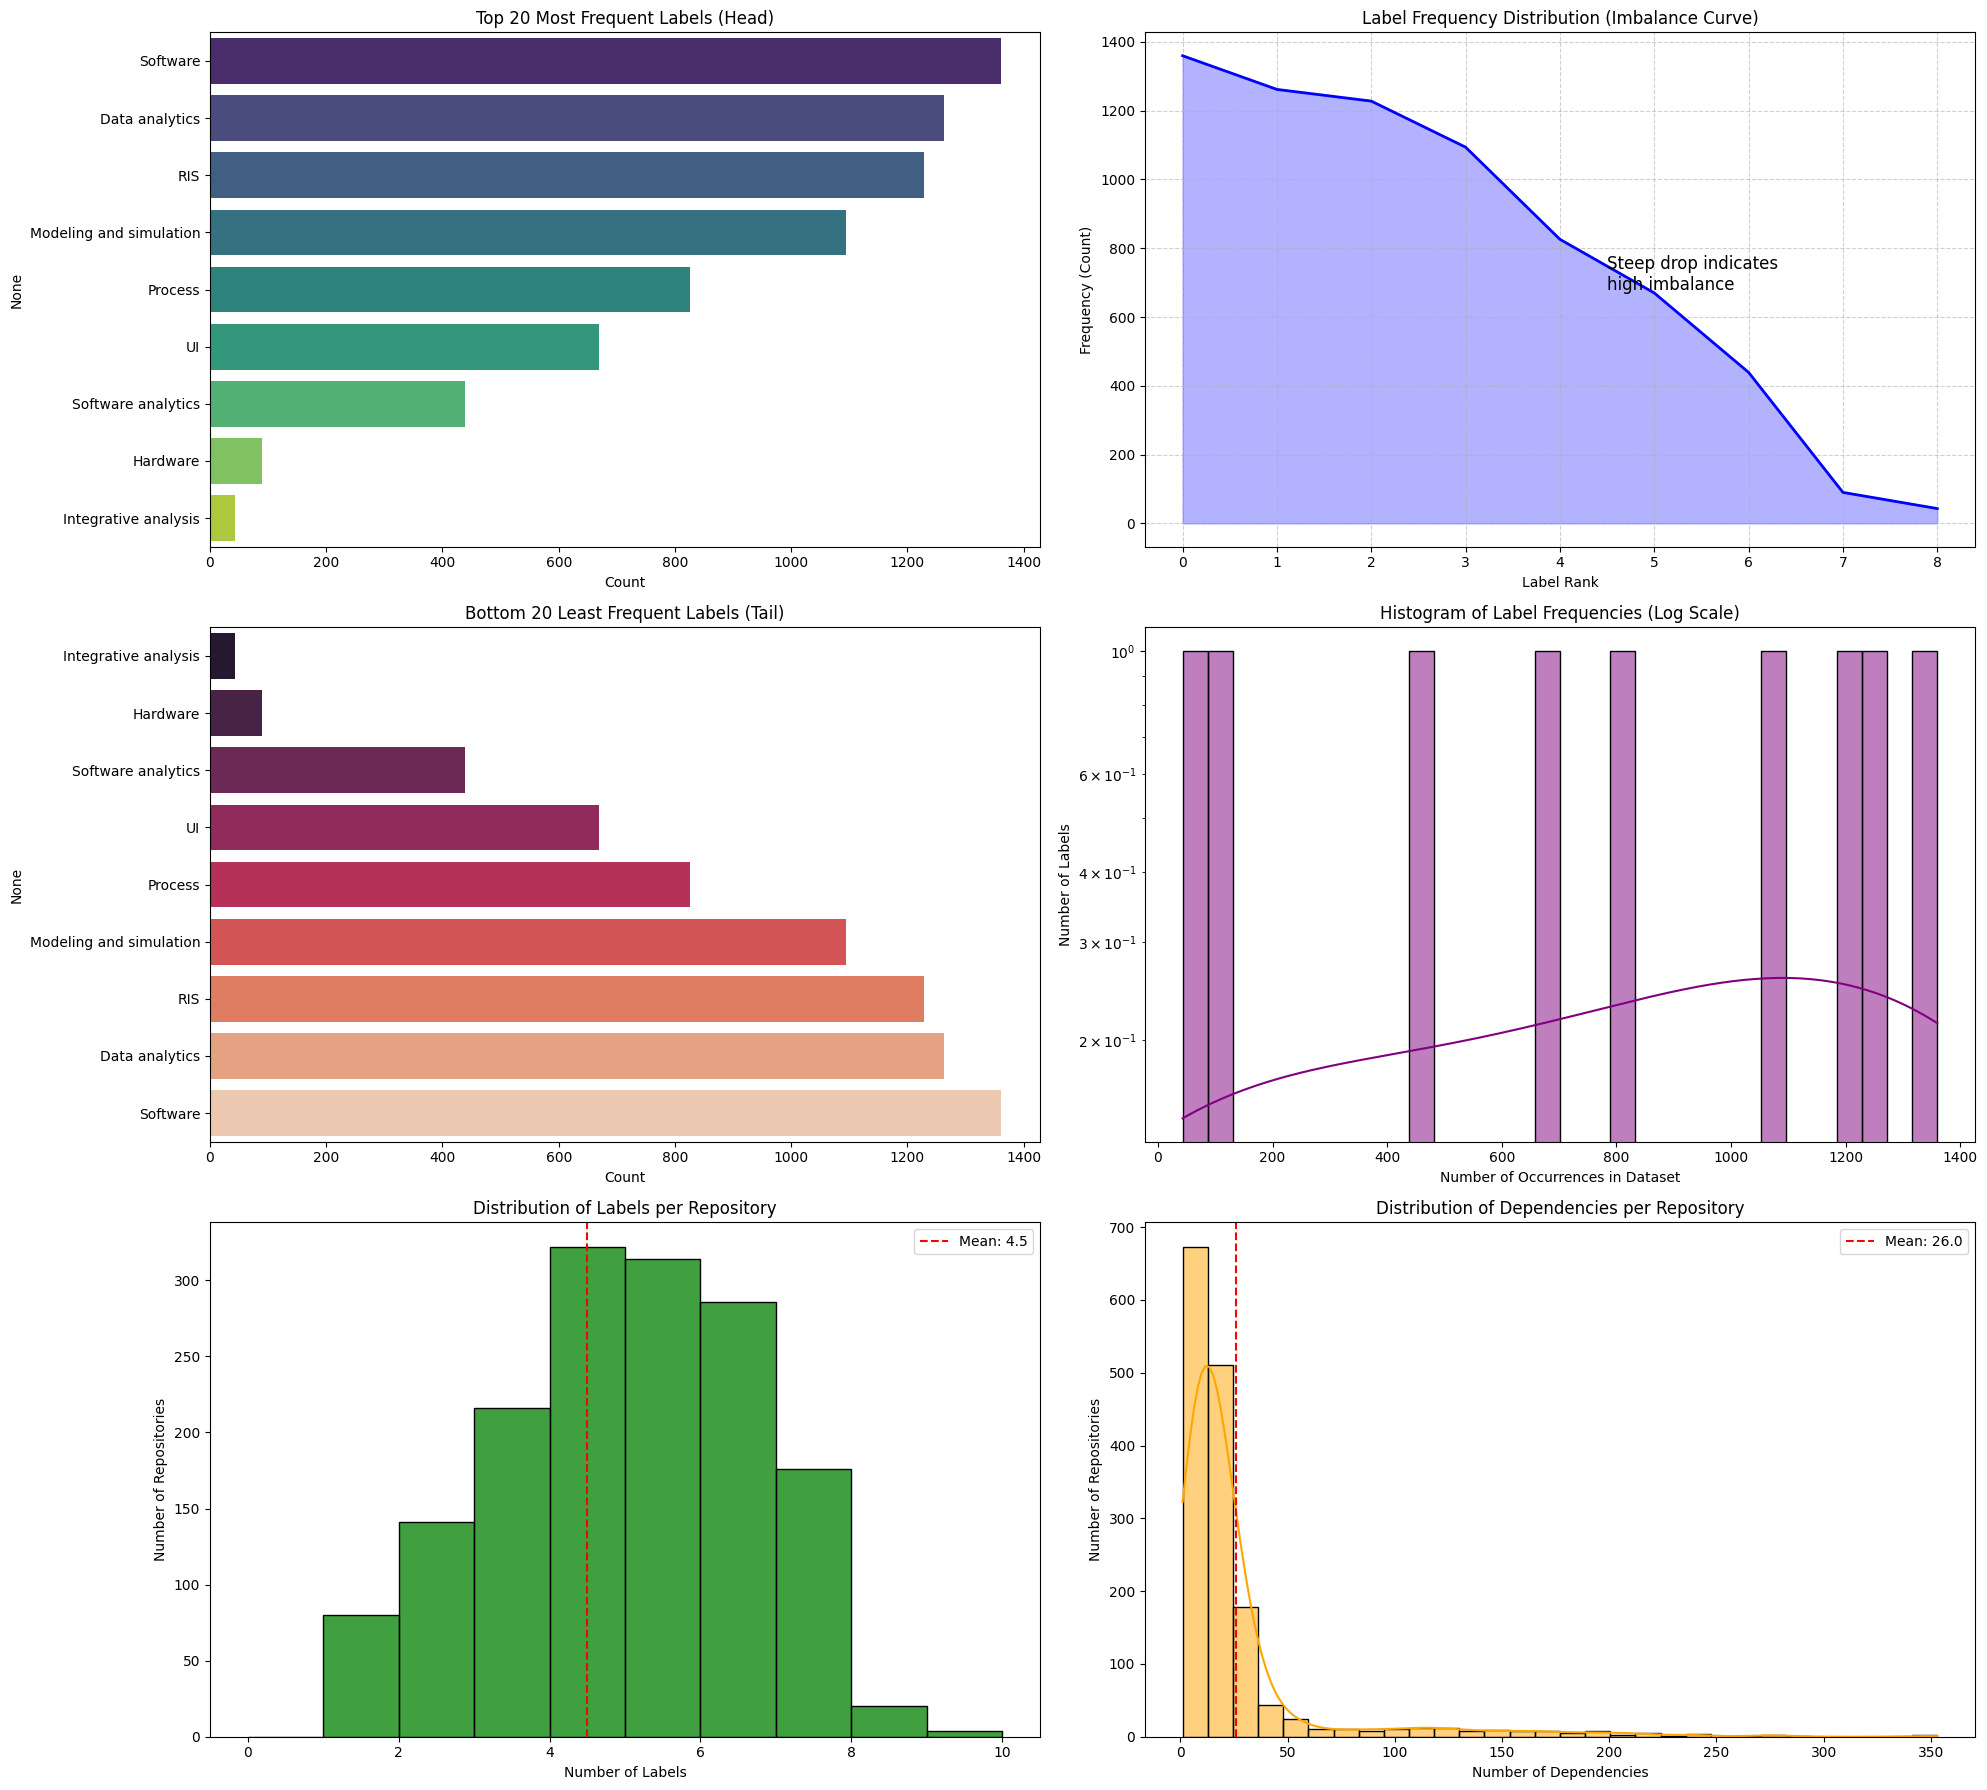

In [19]:
# 3.5 Data Visualization and Imbalance Analysis
if not df.empty:
    print("Visualizing data distributions and Class Imbalance...")
    
    # Flatten lists to count occurrences (Global Stats)
    all_labels = [label for sublist in df['filtered_labels'] for label in sublist]
    all_deps = [dep for sublist in df['filtered_deps'] for dep in sublist]
    
    # Per-Repository Counts (Row-wise Stats)
    labels_per_repo = df['filtered_labels'].apply(len)
    deps_per_repo = df['filtered_deps'].apply(len)
    
    label_counts = pd.Series(all_labels).value_counts()
    dep_counts = pd.Series(all_deps).value_counts()
    
    n_unique_labels = len(label_counts)
    
    # --- Text Statistics ---
    print(f"\n{'='*40}")
    print(f"--- Label Statistics (Global) ---")
    print(f"Total Unique Labels: {n_unique_labels}")
    print(f"Most Frequent Label: '{label_counts.index[0]}' ({label_counts.iloc[0]} occurrences)")
    print(f"Least Frequent Label: '{label_counts.index[-1]}' ({label_counts.iloc[-1]} occurrences)")
    
    print(f"\n--- Per-Repository Statistics (Cardinality) ---")
    print(f"Avg Labels per Repo: {labels_per_repo.mean():.2f} (Median: {labels_per_repo.median()})")
    print(f"Max Labels in a Repo: {labels_per_repo.max()}")
    print(f"Avg Dependencies per Repo: {deps_per_repo.mean():.2f} (Median: {deps_per_repo.median()})")
    print(f"Max Dependencies in a Repo: {deps_per_repo.max()}")
    
    # Identify Imbalance
    print("\n--- Class Imbalance Insights ---")
    print(f"Top 5 Labels account for {label_counts.head(5).sum() / label_counts.sum() * 100:.2f}% of all label assignments.")
    if n_unique_labels > 1:
        print(f"Bottom 50% of labels account for {label_counts.tail(int(n_unique_labels/2)).sum() / label_counts.sum() * 100:.2f}% of all label assignments.")
    print(f"{'='*40}\n")

    # --- Visualization ---
    plt.figure(figsize=(20, 18)) # Increased height for 3 rows
    
    # 1. Top 20 Labels
    plt.subplot(3, 2, 1)
    sns.barplot(x=label_counts.head(20).values, y=label_counts.head(20).index, palette='viridis')
    plt.title(f'Top 20 Most Frequent Labels (Head)')
    plt.xlabel('Count')
    
    # 2. Label Frequency Distribution (Long Tail)
    plt.subplot(3, 2, 2)
    # Plot the sorted counts of all labels
    plt.plot(range(len(label_counts)), label_counts.values, color='blue', linewidth=2)
    plt.fill_between(range(len(label_counts)), label_counts.values, color='blue', alpha=0.3)
    plt.title('Label Frequency Distribution (Imbalance Curve)')
    plt.xlabel('Label Rank')
    plt.ylabel('Frequency (Count)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.text(len(label_counts)*0.5, label_counts.max()*0.5, 'Steep drop indicates\nhigh imbalance', fontsize=12)

    # 3. Bottom 20 Labels (Rare Classes)
    plt.subplot(3, 2, 3)
    # Take the tail, but sort ascending for plotting
    bottom_20 = label_counts.tail(20).sort_values(ascending=True) 
    sns.barplot(x=bottom_20.values, y=bottom_20.index, palette='rocket')
    plt.title('Bottom 20 Least Frequent Labels (Tail)')
    plt.xlabel('Count')
    
    # 4. Histogram of Label Counts (How many labels have X samples?)
    plt.subplot(3, 2, 4)
    sns.histplot(label_counts, bins=30, kde=True, color='purple')
    plt.title('Histogram of Label Frequencies (Log Scale)')
    plt.xlabel('Number of Occurrences in Dataset')
    plt.ylabel('Number of Labels')
    plt.yscale('log') # Log scale to see the rare ones better
    
    # 5. Distribution of Labels per Repository (Multi-label Cardinality)
    plt.subplot(3, 2, 5)
    sns.histplot(labels_per_repo, bins=range(0, labels_per_repo.max() + 2), kde=False, color='green')
    plt.title('Distribution of Labels per Repository')
    plt.xlabel('Number of Labels')
    plt.ylabel('Number of Repositories')
    plt.axvline(labels_per_repo.mean(), color='red', linestyle='--', label=f'Mean: {labels_per_repo.mean():.1f}')
    plt.legend()

    # 6. Distribution of Dependencies per Repository
    plt.subplot(3, 2, 6)
    sns.histplot(deps_per_repo, bins=30, kde=True, color='orange')
    plt.title('Distribution of Dependencies per Repository')
    plt.xlabel('Number of Dependencies')
    plt.ylabel('Number of Repositories')
    plt.axvline(deps_per_repo.mean(), color='red', linestyle='--', label=f'Mean: {deps_per_repo.mean():.1f}')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [20]:
# 4. Train/Test Split and Model Training
if not df.empty:
    print("Splitting data...")
    # Note: Standard train_test_split is random. For rigorous multi-label evaluation, 
    # 'iterative_train_test_split' from scikit-multilearn is recommended to maintain label distribution,
    # but standard split is acceptable for initial benchmarking.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

    # Define models to test
    # CRITICAL UPDATE: Added class_weight='balanced' to handle the high class imbalance identified in EDA.
    models = {
        "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
        "Logistic Regression": OneVsRestClassifier(LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)),
        "Linear SVC": OneVsRestClassifier(LinearSVC(class_weight='balanced', random_state=42, dual=False)), # dual=False for n_samples > n_features
        "MLP Classifier": MLPClassifier(random_state=42, max_iter=500) # MLP doesn't support class_weight directly
    }

    results = []

    for name, clf in models.items():
        print(f"\n{'='*20}")
        print(f"Training {name}...")
        clf.fit(X_train, y_train)

        # 5. Evaluation
        print(f"Evaluating {name}...")
        y_pred = clf.predict(X_test)

        # Calculate metrics
        # Accuracy in multi-label is "Exact Match Ratio" (harsh metric)
        acc = accuracy_score(y_test, y_pred)
        # F1 Micro is best for imbalanced multi-label datasets
        f1_micro = f1_score(y_test, y_pred, average='micro')
        # F1 Macro treats all classes equally (good for checking performance on rare classes)
        f1_macro = f1_score(y_test, y_pred, average='macro')
        # Hamming Loss is the fraction of wrong labels to total labels
        hl = hamming_loss(y_test, y_pred)

        results.append({
            "Model": name,
            "Accuracy": acc,
            "F1 Micro": f1_micro,
            "F1 Macro": f1_macro,
            "Hamming Loss": hl
        })

        print(f"\nClassification Report for {name}:")
        # zero_division=0 handles warnings for classes with no predicted samples
        print(classification_report(y_test, y_pred, target_names=mlb_y.classes_, zero_division=0))

Splitting data...

Training Random Forest...
Evaluating Random Forest...

Classification Report for Random Forest:
                         precision    recall  f1-score   support

         Data analytics       0.98      0.93      0.95       382
               Hardware       1.00      0.48      0.65        27
   Integrative analysis       1.00      0.15      0.27        13
Modeling and simulation       0.97      0.83      0.90       333
                Process       0.98      0.77      0.86       247
                    RIS       0.95      0.90      0.92       355
               Software       0.96      0.89      0.92       408
     Software analytics       0.95      0.53      0.68       108
                     UI       0.97      0.50      0.66       201

              micro avg       0.97      0.81      0.88      2074
              macro avg       0.97      0.66      0.76      2074
           weighted avg       0.97      0.81      0.87      2074
            samples avg       0.93    

C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Evaluating Linear SVC...

Classification Report for Linear SVC:
                         precision    recall  f1-score   support

         Data analytics       1.00      0.92      0.96       382
               Hardware       0.95      0.70      0.81        27
   Integrative analysis       1.00      0.31      0.47        13
Modeling and simulation       0.97      0.92      0.94       333
                Process       0.98      0.92      0.95       247
                    RIS       0.97      0.90      0.93       355
               Software       0.98      0.91      0.94       408
     Software analytics       0.96      0.86      0.91       108
                     UI       0.98      0.88      0.92       201

              micro avg       0.98      0.90      0.94      2074
              macro avg       0.98      0.81      0.87      2074
           weighted avg       0.98      0.90      0.94      2074
            samples avg       0.95      0.87      0.90      2074


Training MLP Classifie

In [23]:
# 5. Training with Cross-Validation and Class Balancing
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, hamming_loss
import numpy as np
import pandas as pd

if not df.empty:
    print("Splitting data...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

    # Define models with class balancing where possible
    models = {
        "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
        "Logistic Regression": OneVsRestClassifier(LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42, max_iter=1000)),
        "Linear SVC": OneVsRestClassifier(LinearSVC(class_weight='balanced', random_state=42, dual='auto', max_iter=2000)),
        "MLP Classifier": MLPClassifier(random_state=42, max_iter=500, early_stopping=True)
    }

    results = []
    cv_results_list = []

    print(f"Training on {X_train.shape[0]} samples, Testing on {X_test.shape[0]} samples.")

    for name, clf in models.items():
        print(f"\n{'='*30}")
        print(f"Processing {name}...")
        
        # 1. Cross-Validation on Training Set
        print(f"  Running 5-Fold Cross-Validation...")
        scoring = ['f1_micro', 'f1_macro', 'accuracy']
        cv_scores = cross_validate(clf, X_train, y_train, cv=5, scoring=scoring, return_train_score=False)
        
        mean_cv_f1_micro = np.mean(cv_scores['test_f1_micro'])
        std_cv_f1_micro = np.std(cv_scores['test_f1_micro'])
        
        print(f"  CV F1 Micro: {mean_cv_f1_micro:.4f} (+/- {std_cv_f1_micro:.4f})")
        
        # 2. Train on Full Training Set
        print(f"  Training on full training set...")
        clf.fit(X_train, y_train)

        # 3. Evaluate on Held-out Test Set
        print(f"  Evaluating on Test Set...")
        y_pred = clf.predict(X_test)

        # Calculate metrics
        acc = accuracy_score(y_test, y_pred)
        f1_micro = f1_score(y_test, y_pred, average='micro')
        f1_macro = f1_score(y_test, y_pred, average='macro')
        hl = hamming_loss(y_test, y_pred)

        results.append({
            "Model": name,
            "Test Accuracy": acc,
            "Test F1 Micro": f1_micro,
            "Test F1 Macro": f1_macro,
            "Test Hamming Loss": hl,
            "CV F1 Micro (Mean)": mean_cv_f1_micro
        })

        print(f"\n  Test Classification Report for {name}:")
        print(classification_report(y_test, y_pred, target_names=mlb_y.classes_, zero_division=0))

    # 6. Comparison
    print(f"\n{'='*30}")
    print("Final Model Comparison:")
    results_df = pd.DataFrame(results)
    # Sort by Test F1 Micro
    display_cols = ["Model", "CV F1 Micro (Mean)", "Test F1 Micro", "Test F1 Macro", "Test Accuracy", "Test Hamming Loss"]
    print(results_df[display_cols].sort_values(by="Test F1 Micro", ascending=False))

Splitting data...
Training on 1091 samples, Testing on 468 samples.

Processing Random Forest...
  Running 5-Fold Cross-Validation...
  CV F1 Micro: 0.8728 (+/- 0.0053)
  Training on full training set...
  Evaluating on Test Set...

  Test Classification Report for Random Forest:
                         precision    recall  f1-score   support

         Data analytics       0.98      0.93      0.95       382
               Hardware       1.00      0.48      0.65        27
   Integrative analysis       1.00      0.15      0.27        13
Modeling and simulation       0.97      0.83      0.90       333
                Process       0.98      0.77      0.86       247
                    RIS       0.95      0.90      0.92       355
               Software       0.96      0.89      0.92       408
     Software analytics       0.95      0.53      0.68       108
                     UI       0.97      0.50      0.66       201

              micro avg       0.97      0.81      0.88      2074
  

Visualizing Model Performance...


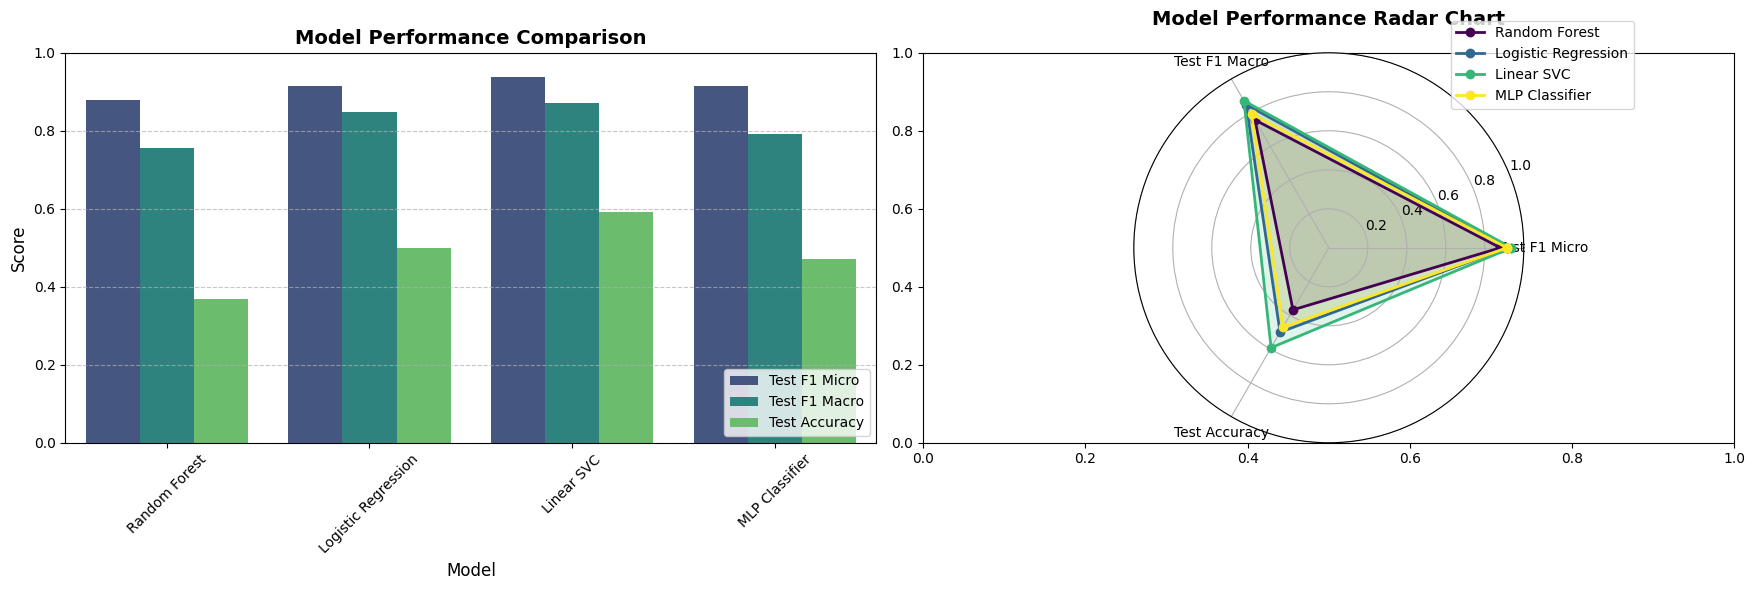


****************************************
🏆 BEST MODEL: Linear SVC
   Test F1 Micro: 0.9367
****************************************

Detailed Stats for Linear SVC:
Model                 Linear SVC
Test Accuracy            0.59188
Test F1 Micro           0.936715
Test F1 Macro           0.870213
Test Hamming Loss       0.059829
CV F1 Micro (Mean)      0.930895


In [24]:
# 7. Visualize Model Comparison
if not results_df.empty:
    print("Visualizing Model Performance...")
    
    # Melt DataFrame for easier plotting with seaborn
    results_melted = results_df.melt(id_vars="Model", 
                                     value_vars=["Test F1 Micro", "Test F1 Macro", "Test Accuracy"],
                                     var_name="Metric", value_name="Score")
    
    # Create figure with two subplots
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Plot 1: Bar chart comparison
    sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric", palette="viridis", ax=axes[0])
    axes[0].set_title("Model Performance Comparison", fontsize=14, fontweight='bold')
    axes[0].set_ylim(0, 1.0)
    axes[0].set_ylabel("Score", fontsize=12)
    axes[0].set_xlabel("Model", fontsize=12)
    axes[0].legend(loc='lower right')
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)
    axes[0].tick_params(axis='x', rotation=45)
    
    # Plot 2: Radar chart for comprehensive view
    from math import pi
    
    # Prepare data for radar chart (normalize metrics to 0-1 scale)
    metrics_for_radar = ["Test F1 Micro", "Test F1 Macro", "Test Accuracy"]
    num_vars = len(metrics_for_radar)
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]  # Complete the circle
    
    ax = axes[1]
    ax = plt.subplot(122, polar=True)
    
    # Plot each model
    colors = plt.cm.viridis(np.linspace(0, 1, len(results_df)))
    for idx, row in results_df.iterrows():
        values = row[metrics_for_radar].values.tolist()
        values += values[:1]  # Complete the circle
        ax.plot(angles, values, 'o-', linewidth=2, label=row['Model'], color=colors[idx])
        ax.fill(angles, values, alpha=0.15, color=colors[idx])
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics_for_radar, size=10)
    ax.set_ylim(0, 1)
    ax.set_title("Model Performance Radar Chart", fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    ax.grid(True)
    
    plt.tight_layout()
    plt.show()

    # Highlight Best Model
    best_model_row = results_df.loc[results_df['Test F1 Micro'].idxmax()]
    best_model_name = best_model_row['Model']
    best_f1_micro = best_model_row['Test F1 Micro']
    
    print(f"\n{'*'*40}")
    print(f"🏆 BEST MODEL: {best_model_name}")
    print(f"   Test F1 Micro: {best_f1_micro:.4f}")
    print(f"{'*'*40}\n")
    
    # Display detailed stats for best model
    print(f"Detailed Stats for {best_model_name}:")
    print(best_model_row.to_string())
    
    # Compare Ensemble vs Individual Models
    if "Ensemble (RF + SVC)" in results_df['Model'].values:
        print(f"\n{'='*50}")
        print("Ensemble vs Individual Component Analysis:")
        print(f"{'='*50}")
        ensemble_row = results_df[results_df['Model'] == "Ensemble (RF + SVC)"].iloc[0]
        rf_row = results_df[results_df['Model'] == "Random Forest"].iloc[0]
        svc_row = results_df[results_df['Model'] == "Linear SVC"].iloc[0]
        
        print(f"\nRandom Forest      F1-Micro: {rf_row['Test F1 Micro']:.4f}")
        print(f"Linear SVC         F1-Micro: {svc_row['Test F1 Micro']:.4f}")
        print(f"Ensemble (RF+SVC)  F1-Micro: {ensemble_row['Test F1 Micro']:.4f}")
        
        improvement_vs_rf = ((ensemble_row['Test F1 Micro'] - rf_row['Test F1 Micro']) / rf_row['Test F1 Micro'] * 100)
        improvement_vs_svc = ((ensemble_row['Test F1 Micro'] - svc_row['Test F1 Micro']) / svc_row['Test F1 Micro'] * 100)
        
        print(f"\nEnsemble improvement over Random Forest: {improvement_vs_rf:+.2f}%")
        print(f"Ensemble improvement over Linear SVC:    {improvement_vs_svc:+.2f}%")

Visualizing Model Performance...


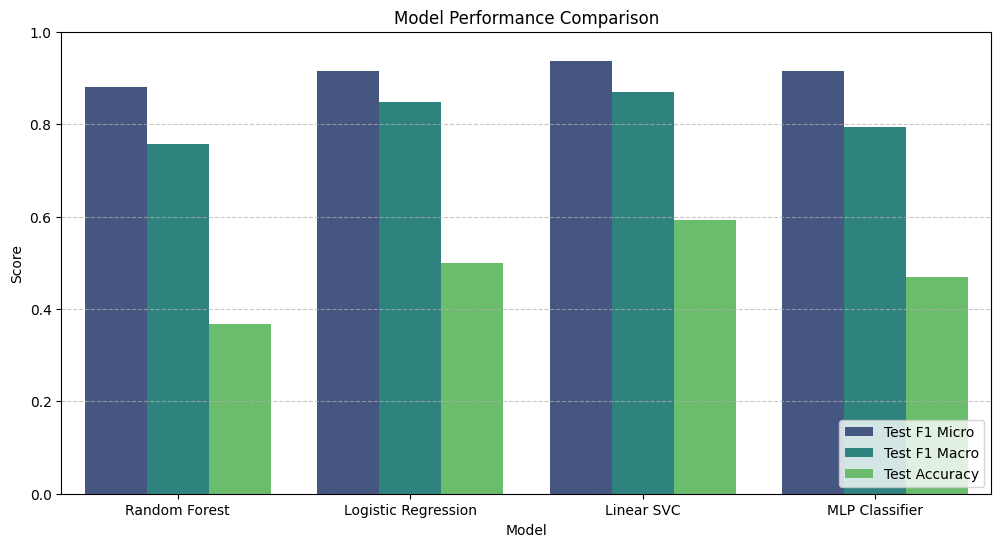


****************************************
🏆 BEST MODEL: Linear SVC
   Test F1 Micro: 0.9367
****************************************

Detailed Stats for Linear SVC:
Model                 Linear SVC
Test Accuracy            0.59188
Test F1 Micro           0.936715
Test F1 Macro           0.870213
Test Hamming Loss       0.059829
CV F1 Micro (Mean)      0.930895


In [25]:
# 7. Visualize Model Comparison
if not results_df.empty:
    print("Visualizing Model Performance...")
    
    # Melt DataFrame for easier plotting with seaborn
    results_melted = results_df.melt(id_vars="Model", 
                                     value_vars=["Test F1 Micro", "Test F1 Macro", "Test Accuracy"],
                                     var_name="Metric", value_name="Score")
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric", palette="viridis")
    plt.title("Model Performance Comparison")
    plt.ylim(0, 1.0)
    plt.ylabel("Score")
    plt.xlabel("Model")
    plt.legend(loc='lower right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Highlight Best Model
    best_model_row = results_df.loc[results_df['Test F1 Micro'].idxmax()]
    best_model_name = best_model_row['Model']
    best_f1_micro = best_model_row['Test F1 Micro']
    
    print(f"\n{'*'*40}")
    print(f"🏆 BEST MODEL: {best_model_name}")
    print(f"   Test F1 Micro: {best_f1_micro:.4f}")
    print(f"{'*'*40}\n")
    
    # Display detailed stats for best model
    print(f"Detailed Stats for {best_model_name}:")
    print(best_model_row.to_string())

In [26]:
# 8. Save the Best Model
import joblib
import os

if not results_df.empty:
    # Identify best model instance
    best_model_name = results_df.loc[results_df['Test F1 Micro'].idxmax()]['Model']
    best_clf = models[best_model_name] # Retrieve the actual trained model object
    
    # Create a dictionary to store all necessary components
    model_bundle = {
        'model': best_clf,
        'mlb_X': mlb_X, # Binarizer for dependencies
        'mlb_y': mlb_y, # Binarizer for labels
        'valid_dependencies': valid_dependencies_lower, # Set of valid dependencies
        'model_name': best_model_name
    }
    
    # Save to file
    save_path = 'best_multilabel_model.joblib'
    joblib.dump(model_bundle, save_path)
    
    print(f"✅ Successfully saved '{best_model_name}' and preprocessors to '{save_path}'")
    print(f"File size: {os.path.getsize(save_path) / 1024 / 1024:.2f} MB")

✅ Successfully saved 'Linear SVC' and preprocessors to 'best_multilabel_model.joblib'
File size: 0.68 MB


In [29]:
# 9. Load and Use the Saved Model (Inference Example)
import joblib

def predict_labels(dependencies, model_path='best_multilabel_model.joblib'):
    """
    Predicts labels for a given list of dependencies using the saved model.
    """
    print(f"Loading model from {model_path}...")
    try:
        bundle = joblib.load(model_path)
        clf = bundle['model']
        mlb_X = bundle['mlb_X']
        mlb_y = bundle['mlb_y']
        valid_deps = bundle['valid_dependencies']
    except FileNotFoundError:
        print("Error: Model file not found. Please train and save the model first.")
        return []

    # Preprocess input
    # 1. Normalize and filter dependencies
    filtered_deps = [d.lower() for d in dependencies if d.lower() in valid_deps]
    
    if not filtered_deps:
        print("Warning: No valid dependencies found in input.")
        return []
    
    # 2. Transform to feature vector
    # mlb.transform expects a list of lists (iterable of iterables)
    X_input = mlb_X.transform([filtered_deps])
    
    # 3. Predict
    y_pred_bin = clf.predict(X_input)
    
    # 4. Inverse transform to get label names
    predicted_labels = mlb_y.inverse_transform(y_pred_bin)
    
    return predicted_labels[0] # Return the tuple of labels for the first (and only) input

# --- Test the Inference Function ---
# Example: A list of dependencies that might imply 'Data Analytics' or 'Modeling'
test_deps = ['pandas', 'numpy', 'scikit-learn', 'matplotlib']

print(f"\nInput Dependencies: {test_deps}")
predicted = predict_labels(test_deps)
print(f"Predicted Labels: {predicted}")


Input Dependencies: ['pandas', 'numpy', 'scikit-learn', 'matplotlib']
Loading model from best_multilabel_model.joblib...
Predicted Labels: ('Data analytics', 'Modeling and simulation')


In [30]:
# 10. Compare Actual vs Predicted on Test Set and Save Results
if 'best_clf' in locals() and 'best_model_name' in locals():
    print(f"Comparing predictions using best model: {best_model_name}")

    # Predict on the full test set
    y_test_pred = best_clf.predict(X_test)

    # Convert binary labels back to strings
    actual_labels = mlb_y.inverse_transform(y_test)
    predicted_labels = mlb_y.inverse_transform(y_test_pred)

    # Create a comparison DataFrame
    comparison_df = pd.DataFrame({
        'Actual Labels': actual_labels,
        'Predicted Labels': predicted_labels
    })

    # Add a column to check for exact matches
    comparison_df['Exact Match'] = comparison_df['Actual Labels'] == comparison_df['Predicted Labels']

    # Save to CSV
    output_csv = 'test_set_predictions.csv'
    comparison_df.to_csv(output_csv, index=False)
    print(f"✅ Saved test set predictions to '{output_csv}'")

    # Display a sample of results
    print("\nSample of Test Predictions (First 20):")
    # Set pandas display options to show full column width for lists
    pd.set_option('display.max_colwidth', None)
    print(comparison_df.head(20))

    # Show some statistics about the predictions
    print("\nPrediction Statistics:")
    print(f"Total Test Samples: {len(comparison_df)}")
    print(f"Exact Matches: {comparison_df['Exact Match'].sum()}")
    print(f"Exact Match Percentage: {comparison_df['Exact Match'].mean() * 100:.2f}%")

    # Show a few examples where the model made a mistake (if any)
    mistakes = comparison_df[~comparison_df['Exact Match']]
    if not mistakes.empty:
        print("\nSample of Mismatches (First 10):")
        print(mistakes.head(10))
else:
    print("⚠️ Error: Model not trained yet. Please run the training cells first.")

Comparing predictions using best model: Linear SVC
✅ Saved test set predictions to 'test_set_predictions.csv'

Sample of Test Predictions (First 20):
                                                                            Actual Labels  \
0                                                                                  (RIS,)   
1                                                                         (RIS, Software)   
2                   (Data analytics, Modeling and simulation, Process, RIS, Software, UI)   
3                            (Data analytics, Modeling and simulation, RIS, Software, UI)   
4                                            (Process, RIS, Software, Software analytics)   
5   (Data analytics, Modeling and simulation, Process, RIS, Software, Software analytics)   
6      (Data analytics, Integrative analysis, Modeling and simulation, RIS, Software, UI)   
7                        (Data analytics, Modeling and simulation, Process, Software, UI)   
8   (Data ana

#### Enseble method

In [35]:
# 5. Training with Cross-Validation, Class Balancing, and Ensemble
from sklearn.model_selection import cross_validate, train_test_split, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, hamming_loss
import numpy as np
import pandas as pd

# Custom Multi-Label Ensemble (Majority Voting)
class MultiLabelEnsemble:
    """Custom ensemble for multi-label classification using majority voting"""
    def __init__(self, estimators):
        self.estimators = estimators
        self.fitted_estimators_ = []
    
    def fit(self, X, y):
        self.fitted_estimators_ = []
        for name, clf in self.estimators:
            print(f"    Training {name} in ensemble...")
            clf.fit(X, y)
            self.fitted_estimators_.append((name, clf))
        return self
    
    def predict(self, X):
        # Collect predictions from all estimators
        predictions = []
        for name, clf in self.fitted_estimators_:
            predictions.append(clf.predict(X))
        
        # Stack predictions: shape (n_estimators, n_samples, n_labels)
        predictions = np.array(predictions)
        
        # Majority voting: if more than half predict 1, output 1
        majority_vote = (predictions.mean(axis=0) >= 0.5).astype(int)
        return majority_vote

# Manual Cross-Validation for Ensemble
def manual_cv_for_ensemble(ensemble_estimators, X, y, cv=5):
    """Manually perform cross-validation for ensemble"""
    kfold = KFold(n_splits=cv, shuffle=True, random_state=42)
    cv_f1_scores = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X)):
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]
        
        # Create fresh ensemble for this fold
        ensemble = MultiLabelEnsemble(ensemble_estimators)
        ensemble.fit(X_train_fold, y_train_fold)
        
        # Predict and score
        y_pred = ensemble.predict(X_val_fold)
        f1_micro = f1_score(y_val_fold, y_pred, average='micro')
        cv_f1_scores.append(f1_micro)
    
    return np.mean(cv_f1_scores), np.std(cv_f1_scores)

if not df.empty:
    print("Splitting data...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

    # Define base models with class balancing where possible
    rf_clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    lr_clf = OneVsRestClassifier(LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42, max_iter=1000))
    svc_clf = OneVsRestClassifier(LinearSVC(class_weight='balanced', random_state=42, dual='auto', max_iter=2000))
    
    # Ensemble estimators definition (for CV and final training)
    ensemble_estimators = [
        ('Random Forest', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
        ('Linear SVC', OneVsRestClassifier(LinearSVC(class_weight='balanced', random_state=42, dual='auto', max_iter=2000)))
    ]
    
    # Create custom ensemble
    ensemble_clf = MultiLabelEnsemble(ensemble_estimators)
    
    models = {
        "Random Forest": rf_clf,
        "Logistic Regression": lr_clf,
        "Linear SVC": svc_clf,
        "Ensemble (RF + SVC)": ensemble_clf
    }

    results = []

    print(f"Training on {X_train.shape[0]} samples, Testing on {X_test.shape[0]} samples.")

    for name, clf in models.items():
        print(f"\n{'='*30}")
        print(f"Processing {name}...")
        
        # 1. Cross-Validation on Training Set
        if name != "Ensemble (RF + SVC)":
            print(f"  Running 5-Fold Cross-Validation...")
            scoring = ['f1_micro', 'f1_macro', 'accuracy']
            cv_scores = cross_validate(clf, X_train, y_train, cv=5, scoring=scoring, return_train_score=False)
            
            mean_cv_f1_micro = np.mean(cv_scores['test_f1_micro'])
            std_cv_f1_micro = np.std(cv_scores['test_f1_micro'])
            
            print(f"  CV F1 Micro: {mean_cv_f1_micro:.4f} (+/- {std_cv_f1_micro:.4f})")
        else:
            # Manual CV for ensemble
            print(f"  Running 5-Fold Cross-Validation (manual)...")
            mean_cv_f1_micro, std_cv_f1_micro = manual_cv_for_ensemble(ensemble_estimators, X_train, y_train, cv=5)
            print(f"  CV F1 Micro: {mean_cv_f1_micro:.4f} (+/- {std_cv_f1_micro:.4f})")
        
        # 2. Train on Full Training Set
        print(f"  Training on full training set...")
        clf.fit(X_train, y_train)

        # 3. Evaluate on Held-out Test Set
        print(f"  Evaluating on Test Set...")
        y_pred = clf.predict(X_test)

        # Calculate metrics
        acc = accuracy_score(y_test, y_pred)
        f1_micro = f1_score(y_test, y_pred, average='micro')
        f1_macro = f1_score(y_test, y_pred, average='macro')
        hl = hamming_loss(y_test, y_pred)

        results.append({
            "Model": name,
            "Test Accuracy": acc,
            "Test F1 Micro": f1_micro,
            "Test F1 Macro": f1_macro,
            "Test Hamming Loss": hl,
            "CV F1 Micro (Mean)": mean_cv_f1_micro
        })

        print(f"\n  Test Classification Report for {name}:")
        print(classification_report(y_test, y_pred, target_names=mlb_y.classes_, zero_division=0))

    # 6. Comparison
    print(f"\n{'='*30}")
    print("Final Model Comparison:")
    results_df = pd.DataFrame(results)
    # Sort by Test F1 Micro
    display_cols = ["Model", "CV F1 Micro (Mean)", "Test F1 Micro", "Test F1 Macro", "Test Accuracy", "Test Hamming Loss"]
    print(results_df[display_cols].sort_values(by="Test F1 Micro", ascending=False))

Splitting data...
Training on 1091 samples, Testing on 468 samples.

Processing Random Forest...
  Running 5-Fold Cross-Validation...
  CV F1 Micro: 0.8728 (+/- 0.0053)
  Training on full training set...
  Evaluating on Test Set...

  Test Classification Report for Random Forest:
                         precision    recall  f1-score   support

         Data analytics       0.98      0.93      0.95       382
               Hardware       1.00      0.48      0.65        27
   Integrative analysis       1.00      0.15      0.27        13
Modeling and simulation       0.97      0.83      0.90       333
                Process       0.98      0.77      0.86       247
                    RIS       0.95      0.90      0.92       355
               Software       0.96      0.89      0.92       408
     Software analytics       0.95      0.53      0.68       108
                     UI       0.97      0.50      0.66       201

              micro avg       0.97      0.81      0.88      2074
  

In [36]:
# 8. Save the Best Model, Test Inference, and Compare Predictions
import joblib
import os

if not results_df.empty:
    # Identify best model instance
    best_model_name = results_df.loc[results_df['Test F1 Micro'].idxmax()]['Model']
    best_clf = models[best_model_name] # Retrieve the actual trained model object
    
    # Create a dictionary to store all necessary components
    model_bundle = {
        'model': best_clf,
        'mlb_X': mlb_X, # Binarizer for dependencies
        'mlb_y': mlb_y, # Binarizer for labels
        'valid_dependencies': valid_dependencies_lower, # Set of valid dependencies
        'model_name': best_model_name
    }
    
    # Save to file
    save_path = 'best_multilabel_model.joblib'
    joblib.dump(model_bundle, save_path)
    
    print(f"✅ Successfully saved '{best_model_name}' and preprocessors to '{save_path}'")
    print(f"File size: {os.path.getsize(save_path) / 1024 / 1024:.2f} MB")

    # 9. Define and Test Inference Function
    def predict_labels(dependencies, model_path='best_multilabel_model.joblib'):
        """
        Predicts labels for a given list of dependencies using the saved model.
        """
        try:
            bundle = joblib.load(model_path)
            clf = bundle['model']
            mlb_X = bundle['mlb_X']
            mlb_y = bundle['mlb_y']
            valid_deps = bundle['valid_dependencies']
        except FileNotFoundError:
            print("Error: Model file not found. Please train and save the model first.")
            return []
    
        # Preprocess input
        # 1. Normalize and filter dependencies
        filtered_deps = [d.lower() for d in dependencies if d.lower() in valid_deps]
        
        if not filtered_deps:
            print("Warning: No valid dependencies found in input.")
            return []
        
        # 2. Transform to feature vector
        X_input = mlb_X.transform([filtered_deps])
        
        # 3. Predict
        y_pred_bin = clf.predict(X_input)
        
        # 4. Inverse transform to get label names
        predicted_labels = mlb_y.inverse_transform(y_pred_bin)
        
        return predicted_labels[0] # Return the tuple of labels for the first (and only) input
    
    # --- Test the Inference Function ---
    print(f"\n{'='*50}")
    print("Testing Inference Function on Sample Dependencies")
    print(f"{'='*50}")
    test_deps = ['pandas', 'numpy', 'scikit-learn', 'matplotlib']
    print(f"Input Dependencies: {test_deps}")
    predicted = predict_labels(test_deps)
    print(f"Predicted Labels: {predicted}\n")

    # 10. Compare Actual vs Predicted on Test Set and Save Results
    print(f"{'='*50}")
    print(f"Comparing predictions using best model: {best_model_name}")
    print(f"{'='*50}")

    # Predict on the full test set
    y_test_pred = best_clf.predict(X_test)

    # Convert binary labels back to strings
    actual_labels = mlb_y.inverse_transform(y_test)
    predicted_labels = mlb_y.inverse_transform(y_test_pred)

    # Create a comparison DataFrame
    comparison_df = pd.DataFrame({
        'Actual Labels': actual_labels,
        'Predicted Labels': predicted_labels
    })

    # Add a column to check for exact matches
    comparison_df['Exact Match'] = comparison_df['Actual Labels'] == comparison_df['Predicted Labels']

    # Save to CSV
    output_csv = 'test_set_predictions.csv'
    comparison_df.to_csv(output_csv, index=False)
    print(f"\n✅ Saved test set predictions to '{output_csv}'")

    # Display a sample of results
    print("\n" + "="*50)
    print("Sample of Test Predictions (First 20):")
    print("="*50)
    pd.set_option('display.max_colwidth', None)
    pd.set_option('display.width', None)
    print(comparison_df.head(20).to_string(index=False))

    # Show some statistics about the predictions
    print("\n" + "="*50)
    print("Prediction Statistics:")
    print("="*50)
    print(f"Total Test Samples: {len(comparison_df)}")
    print(f"Exact Matches: {comparison_df['Exact Match'].sum()}")
    print(f"Exact Match Percentage: {comparison_df['Exact Match'].mean() * 100:.2f}%")

    # Show a few examples where the model made a mistake (if any)
    mistakes = comparison_df[~comparison_df['Exact Match']]
    if not mistakes.empty:
        print("\n" + "="*50)
        print("Sample of Mismatches (First 10):")
        print("="*50)
        print(mistakes.head(10).to_string(index=False))
    else:
        print("\n🎉 Perfect predictions! All test samples matched exactly.")
else:
    print("⚠️ Error: Model not trained yet. Please run the training cells first.")

✅ Successfully saved 'Ensemble (RF + SVC)' and preprocessors to 'best_multilabel_model.joblib'
File size: 25.98 MB

Testing Inference Function on Sample Dependencies
Input Dependencies: ['pandas', 'numpy', 'scikit-learn', 'matplotlib']
Predicted Labels: ('Data analytics', 'Modeling and simulation')

Comparing predictions using best model: Ensemble (RF + SVC)

✅ Saved test set predictions to 'test_set_predictions.csv'

Sample of Test Predictions (First 20):
                                                                        Actual Labels                                                                      Predicted Labels  Exact Match
                                                                               (RIS,)                                                                                (RIS,)         True
                                                                      (RIS, Software)                                                                                    

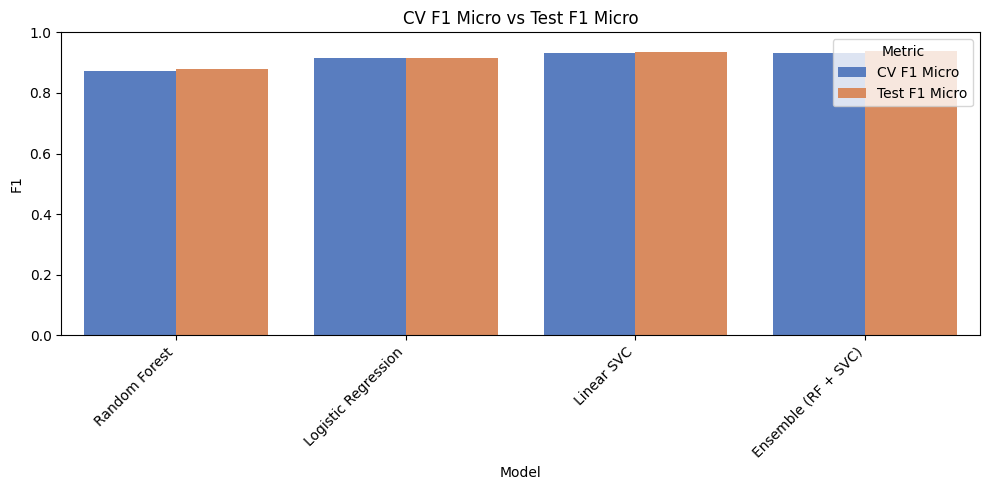

C:\Users\eggoni\AppData\Local\Temp\ipykernel_23380\2369281910.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='Test Hamming Loss', palette='rocket')


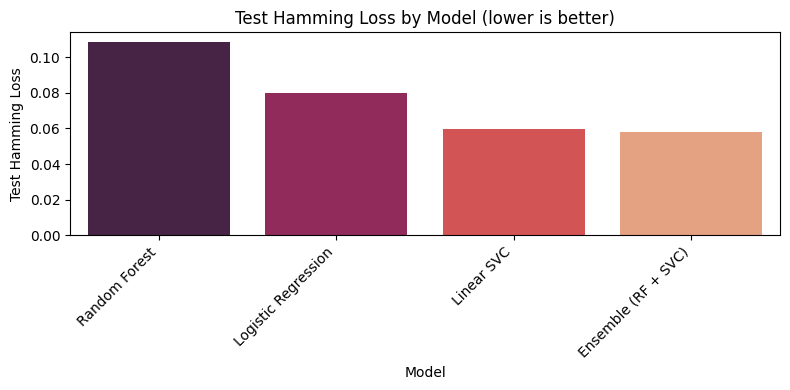

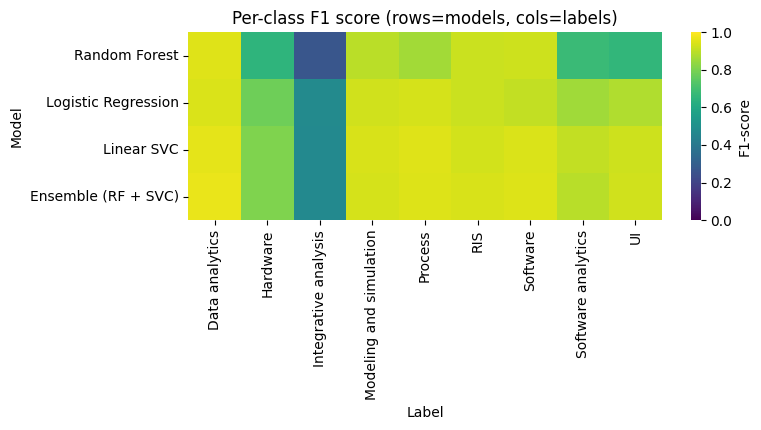

In [37]:

# --- Additional comparison plots: CV vs Test, Hamming Loss, Per-class F1 heatmap ---
if 'results_df' in globals() and not results_df.empty and 'models' in globals() and 'mlb_y' in globals():
    try:
        import matplotlib.pyplot as plt
        import seaborn as sns

        # Prepare barplot of CV F1 Micro vs Test F1 Micro
        comp_df = results_df.copy()
        comp_df = comp_df.rename(columns={'Test F1 Micro': 'Test F1 Micro', 'CV F1 Micro (Mean)': 'CV F1 Micro'})
        melt_df = comp_df.melt(id_vars='Model', value_vars=['CV F1 Micro', 'Test F1 Micro'],
                               var_name='Metric', value_name='F1')

        plt.figure(figsize=(10, 5))
        sns.barplot(data=melt_df, x='Model', y='F1', hue='Metric', palette='muted')
        plt.title('CV F1 Micro vs Test F1 Micro')
        plt.ylim(0, 1)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

        # Hamming Loss per model (if present in results_df)
        if 'Test Hamming Loss' in results_df.columns:
            plt.figure(figsize=(8, 4))
            sns.barplot(data=results_df, x='Model', y='Test Hamming Loss', palette='rocket')
            plt.title('Test Hamming Loss by Model (lower is better)')
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()
            plt.show()

        # Per-class F1 heatmap for each model
        # compute per-class f1s by predicting with each trained model on X_test
        per_class = {}
        for name, clf in models.items():
            try:
                y_pred = clf.predict(X_test)
                f1s = f1_score(y_test, y_pred, average=None)  # one value per class
                per_class[name] = f1s
            except Exception:
                # skip models that cannot predict here
                continue

        if per_class:
            f1_df = pd.DataFrame(per_class, index=mlb_y.classes_).T  # models x classes
            # limit figure size reasonably
            figsize = (max(8, f1_df.shape[1] * 0.3 + 4), max(4, f1_df.shape[0] * 0.6 + 2))
            plt.figure(figsize=figsize)
            sns.heatmap(f1_df, cmap='viridis', vmin=0, vmax=1, cbar_kws={'label': 'F1-score'})
            plt.title('Per-class F1 score (rows=models, cols=labels)')
            plt.xlabel('Label')
            plt.ylabel('Model')
            plt.xticks(rotation=90)
            plt.yticks(rotation=0)
            plt.tight_layout()
            plt.show()
        else:
            print("No per-class F1 data available (prediction step skipped for some models).")

    except Exception as e:
        print(f"Plotting error: {e}")
else:
    print("results_df, models or mlb_y not available for plotting.")

In [38]:
!pip install xgboost lightgbm catboost

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/72.0 MB ? eta -:--:--
   -- ------------------------------------- 3.9/72.0 MB 15.9 MB/s eta 0:00:05
   ---- ----------------------------------- 8.7/72.0 MB 18.6 MB/s eta 0:00:04
   -------- ------------------------------- 14.4/72.0 MB 21.3 MB/s eta 0:00:03
   ----------- ---------------------------- 19.9/72.0 MB 22.6 MB/s eta 0:00:03
   -------------- ------------------------- 25.7/72.0 MB 23.4 MB/s eta 0:00:02
   ----------------- ---------------------- 31.2/72.0 MB 23.8 MB/s eta 0:00:02
   -------------------- ------------------- 36.2/72.0 MB 23.8 MB/s eta 0:00:02
   ----------------------- ---------------- 41.4/72.0 MB 23.9 MB/s eta 0:00:02
   -------------------------- ------------- 46.9/72.0 MB 24.1 MB/s eta 0:00:02
   ---------------------------- ----------- 52.2/72.0 MB 24.2 MB/s eta 0:


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [39]:
# 5. Training with Cross-Validation, Class Balancing, and Gradient Boosting Models
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, hamming_loss
import numpy as np
import pandas as pd

# Import gradient boosting libraries
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

if not df.empty:
    print("Splitting data...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

    # Define models with class balancing where possible
    models = {
        "Random Forest": RandomForestClassifier(
            n_estimators=100, 
            class_weight='balanced', 
            random_state=42
        ),
        "Logistic Regression": OneVsRestClassifier(
            LogisticRegression(
                solver='liblinear', 
                class_weight='balanced', 
                random_state=42, 
                max_iter=1000
            )
        ),
        "Linear SVC": OneVsRestClassifier(
            LinearSVC(
                class_weight='balanced', 
                random_state=42, 
                dual='auto', 
                max_iter=2000
            )
        ),
        "XGBoost": OneVsRestClassifier(
            xgb.XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                random_state=42,
                eval_metric='logloss',
                use_label_encoder=False
            )
        ),
        "LightGBM": OneVsRestClassifier(
            lgb.LGBMClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                random_state=42,
                verbose=-1,
                class_weight='balanced'
            )
        ),
        "CatBoost": OneVsRestClassifier(
            CatBoostClassifier(
                iterations=100,
                depth=6,
                learning_rate=0.1,
                random_state=42,
                verbose=False,
                auto_class_weights='Balanced'
            )
        )
    }

    results = []

    print(f"\n{'='*50}")
    print(f"Training on {X_train.shape[0]} samples")
    print(f"Testing on {X_test.shape[0]} samples")
    print(f"Total Models: {len(models)}")
    print(f"{'='*50}")

    for name, clf in models.items():
        print(f"\n{'='*30}")
        print(f"Processing {name}...")
        
        # 1. Cross-Validation on Training Set
        print(f"  Running 5-Fold Cross-Validation...")
        scoring = ['f1_micro', 'f1_macro', 'accuracy']
        
        try:
            cv_scores = cross_validate(
                clf, X_train, y_train, 
                cv=5, 
                scoring=scoring, 
                return_train_score=False,
                error_score='raise'
            )
            
            mean_cv_f1_micro = np.mean(cv_scores['test_f1_micro'])
            std_cv_f1_micro = np.std(cv_scores['test_f1_micro'])
            
            print(f"  CV F1 Micro: {mean_cv_f1_micro:.4f} (+/- {std_cv_f1_micro:.4f})")
        except Exception as e:
            print(f"  ⚠️ CV failed for {name}: {e}")
            mean_cv_f1_micro = 0.0
            std_cv_f1_micro = 0.0
        
        # 2. Train on Full Training Set
        print(f"  Training on full training set...")
        clf.fit(X_train, y_train)

        # 3. Evaluate on Held-out Test Set
        print(f"  Evaluating on Test Set...")
        y_pred = clf.predict(X_test)

        # Calculate metrics
        acc = accuracy_score(y_test, y_pred)
        f1_micro = f1_score(y_test, y_pred, average='micro')
        f1_macro = f1_score(y_test, y_pred, average='macro')
        hl = hamming_loss(y_test, y_pred)

        results.append({
            "Model": name,
            "Test Accuracy": acc,
            "Test F1 Micro": f1_micro,
            "Test F1 Macro": f1_macro,
            "Test Hamming Loss": hl,
            "CV F1 Micro (Mean)": mean_cv_f1_micro
        })

        print(f"\n  Test Classification Report for {name}:")
        print(classification_report(y_test, y_pred, target_names=mlb_y.classes_, zero_division=0))

    # 6. Comparison
    print(f"\n{'='*50}")
    print("📊 FINAL MODEL COMPARISON")
    print(f"{'='*50}")
    results_df = pd.DataFrame(results)
    # Sort by Test F1 Micro
    display_cols = ["Model", "CV F1 Micro (Mean)", "Test F1 Micro", "Test F1 Macro", "Test Accuracy", "Test Hamming Loss"]
    results_sorted = results_df[display_cols].sort_values(by="Test F1 Micro", ascending=False)
    print(results_sorted.to_string(index=False))
    
    # Highlight top 3
    print(f"\n{'='*50}")
    print("🏆 TOP 3 MODELS:")
    print(f"{'='*50}")
    top3 = results_df.nlargest(3, 'Test F1 Micro')
    for idx, (i, row) in enumerate(top3.iterrows(), 1):
        print(f"{idx}. {row['Model']}")
        print(f"   Test F1 Micro: {row['Test F1 Micro']:.4f}")
        print(f"   CV F1 Micro:   {row['CV F1 Micro (Mean)']:.4f}")
        print(f"   Test Accuracy: {row['Test Accuracy']:.4f}")
        print()

Splitting data...

Training on 1091 samples
Testing on 468 samples
Total Models: 6

Processing Random Forest...
  Running 5-Fold Cross-Validation...
  CV F1 Micro: 0.8728 (+/- 0.0053)
  Training on full training set...
  Evaluating on Test Set...

  Test Classification Report for Random Forest:
                         precision    recall  f1-score   support

         Data analytics       0.98      0.93      0.95       382
               Hardware       1.00      0.48      0.65        27
   Integrative analysis       1.00      0.15      0.27        13
Modeling and simulation       0.97      0.83      0.90       333
                Process       0.98      0.77      0.86       247
                    RIS       0.95      0.90      0.92       355
               Software       0.96      0.89      0.92       408
     Software analytics       0.95      0.53      0.68       108
                     UI       0.97      0.50      0.66       201

              micro avg       0.97      0.81      0.

C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [16:09:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [16:09:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [16:09:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [16:09:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\lear

  CV F1 Micro: 0.9291 (+/- 0.0059)
  Training on full training set...


C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [16:10:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [16:10:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [16:10:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [16:10:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\lear

  Evaluating on Test Set...

  Test Classification Report for XGBoost:
                         precision    recall  f1-score   support

         Data analytics       0.98      0.92      0.95       382
               Hardware       1.00      0.67      0.80        27
   Integrative analysis       0.75      0.23      0.35        13
Modeling and simulation       0.99      0.92      0.95       333
                Process       1.00      0.92      0.96       247
                    RIS       0.98      0.91      0.94       355
               Software       0.96      0.92      0.94       408
     Software analytics       0.94      0.87      0.90       108
                     UI       0.99      0.87      0.93       201

              micro avg       0.98      0.90      0.94      2074
              macro avg       0.95      0.80      0.86      2074
           weighted avg       0.98      0.90      0.94      2074
            samples avg       0.95      0.88      0.90      2074


Processing Ligh

C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, b

  CV F1 Micro: 0.8918 (+/- 0.0046)
  Training on full training set...
  Evaluating on Test Set...


C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, b


  Test Classification Report for LightGBM:
                         precision    recall  f1-score   support

         Data analytics       0.99      0.88      0.93       382
               Hardware       0.32      0.85      0.46        27
   Integrative analysis       0.18      0.46      0.26        13
Modeling and simulation       0.98      0.85      0.91       333
                Process       0.99      0.91      0.95       247
                    RIS       0.99      0.85      0.92       355
               Software       0.97      0.83      0.90       408
     Software analytics       0.92      0.86      0.89       108
                     UI       0.97      0.84      0.90       201

              micro avg       0.94      0.86      0.90      2074
              macro avg       0.81      0.82      0.79      2074
           weighted avg       0.97      0.86      0.91      2074
            samples avg       0.90      0.82      0.84      2074


Processing CatBoost...
  Running 5-Fold Cr

In [41]:
# 5. Training with Cross-Validation, Class Balancing, Gradient Boosting, and Ensemble
from sklearn.model_selection import cross_validate, train_test_split, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, hamming_loss
import numpy as np
import pandas as pd

# Import gradient boosting libraries
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Custom Multi-Label Ensemble (Majority Voting)
class MultiLabelEnsemble:
    """Custom ensemble for multi-label classification using majority voting"""
    def __init__(self, estimators):
        self.estimators = estimators
        self.fitted_estimators_ = []
    
    def fit(self, X, y):
        self.fitted_estimators_ = []
        for name, clf in self.estimators:
            print(f"    Training {name} in ensemble...")
            clf.fit(X, y)
            self.fitted_estimators_.append((name, clf))
        return self
    
    def predict(self, X):
        # Collect predictions from all estimators
        predictions = []
        for name, clf in self.fitted_estimators_:
            predictions.append(clf.predict(X))
        
        # Stack predictions: shape (n_estimators, n_samples, n_labels)
        predictions = np.array(predictions)
        
        # Majority voting: if more than half predict 1, output 1
        majority_vote = (predictions.mean(axis=0) >= 0.5).astype(int)
        return majority_vote

# Manual Cross-Validation for Ensemble
def manual_cv_for_ensemble(ensemble_estimators, X, y, cv=5):
    """Manually perform cross-validation for ensemble"""
    kfold = KFold(n_splits=cv, shuffle=True, random_state=42)
    cv_f1_scores = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(X)):
        X_train_fold, X_val_fold = X[train_idx], X[val_idx]
        y_train_fold, y_val_fold = y[train_idx], y[val_idx]
        
        # Create fresh ensemble for this fold
        ensemble = MultiLabelEnsemble(ensemble_estimators)
        ensemble.fit(X_train_fold, y_train_fold)
        
        # Predict and score
        y_pred = ensemble.predict(X_val_fold)
        f1_micro = f1_score(y_val_fold, y_pred, average='micro')
        cv_f1_scores.append(f1_micro)
    
    return np.mean(cv_f1_scores), np.std(cv_f1_scores)

if not df.empty:
    print("Splitting data...")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

    # Ensemble estimators definition (for CV and final training)
    ensemble_estimators = [
        ('Random Forest', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
        ('Linear SVC', OneVsRestClassifier(LinearSVC(class_weight='balanced', random_state=42, dual='auto', max_iter=2000)))
    ]
    
    # Create custom ensemble
    ensemble_clf = MultiLabelEnsemble(ensemble_estimators)

    # Define models with class balancing where possible
    models = {
        "Random Forest": RandomForestClassifier(
            n_estimators=100, 
            class_weight='balanced', 
            random_state=42
        ),
        "Logistic Regression": OneVsRestClassifier(
            LogisticRegression(
                solver='liblinear', 
                class_weight='balanced', 
                random_state=42, 
                max_iter=1000
            )
        ),
        "Linear SVC": OneVsRestClassifier(
            LinearSVC(
                class_weight='balanced', 
                random_state=42, 
                dual='auto', 
                max_iter=2000
            )
        ),
        "XGBoost": OneVsRestClassifier(
            xgb.XGBClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                random_state=42,
                eval_metric='logloss',
                use_label_encoder=False
            )
        ),
        "LightGBM": OneVsRestClassifier(
            lgb.LGBMClassifier(
                n_estimators=100,
                max_depth=6,
                learning_rate=0.1,
                random_state=42,
                verbose=-1,
                class_weight='balanced'
            )
        ),
        "CatBoost": OneVsRestClassifier(
            CatBoostClassifier(
                iterations=100,
                depth=6,
                learning_rate=0.1,
                random_state=42,
                verbose=False,
                auto_class_weights='Balanced'
            )
        ),
        "Ensemble (RF + SVC)": ensemble_clf
    }

    results = []

    print(f"\n{'='*50}")
    print(f"Training on {X_train.shape[0]} samples")
    print(f"Testing on {X_test.shape[0]} samples")
    print(f"Total Models: {len(models)}")
    print(f"{'='*50}")

    for name, clf in models.items():
        print(f"\n{'='*30}")
        print(f"Processing {name}...")
        
        # 1. Cross-Validation on Training Set
        if name != "Ensemble (RF + SVC)":
            print(f"  Running 5-Fold Cross-Validation...")
            scoring = ['f1_micro', 'f1_macro', 'accuracy']
            
            try:
                cv_scores = cross_validate(
                    clf, X_train, y_train, 
                    cv=5, 
                    scoring=scoring, 
                    return_train_score=False,
                    error_score='raise'
                )
                
                mean_cv_f1_micro = np.mean(cv_scores['test_f1_micro'])
                std_cv_f1_micro = np.std(cv_scores['test_f1_micro'])
                
                print(f"  CV F1 Micro: {mean_cv_f1_micro:.4f} (+/- {std_cv_f1_micro:.4f})")
            except Exception as e:
                print(f"  ⚠️ CV failed for {name}: {e}")
                mean_cv_f1_micro = 0.0
                std_cv_f1_micro = 0.0
        else:
            # Manual CV for ensemble
            print(f"  Running 5-Fold Cross-Validation (manual)...")
            mean_cv_f1_micro, std_cv_f1_micro = manual_cv_for_ensemble(ensemble_estimators, X_train, y_train, cv=5)
            print(f"  CV F1 Micro: {mean_cv_f1_micro:.4f} (+/- {std_cv_f1_micro:.4f})")
        
        # 2. Train on Full Training Set
        print(f"  Training on full training set...")
        clf.fit(X_train, y_train)

        # 3. Evaluate on Held-out Test Set
        print(f"  Evaluating on Test Set...")
        y_pred = clf.predict(X_test)

        # Calculate metrics
        acc = accuracy_score(y_test, y_pred)
        f1_micro = f1_score(y_test, y_pred, average='micro')
        f1_macro = f1_score(y_test, y_pred, average='macro')
        hl = hamming_loss(y_test, y_pred)

        results.append({
            "Model": name,
            "Test Accuracy": acc,
            "Test F1 Micro": f1_micro,
            "Test F1 Macro": f1_macro,
            "Test Hamming Loss": hl,
            "CV F1 Micro (Mean)": mean_cv_f1_micro
        })

        print(f"\n  Test Classification Report for {name}:")
        print(classification_report(y_test, y_pred, target_names=mlb_y.classes_, zero_division=0))

    # 6. Comparison
    print(f"\n{'='*50}")
    print("📊 FINAL MODEL COMPARISON (ALL 7 MODELS)")
    print(f"{'='*50}")
    results_df = pd.DataFrame(results)
    # Sort by Test F1 Micro
    display_cols = ["Model", "CV F1 Micro (Mean)", "Test F1 Micro", "Test F1 Macro", "Test Accuracy", "Test Hamming Loss"]
    results_sorted = results_df[display_cols].sort_values(by="Test F1 Micro", ascending=False)
    print(results_sorted.to_string(index=False))
    
    # Highlight top 3
    print(f"\n{'='*50}")
    print("🏆 TOP 3 MODELS:")
    print(f"{'='*50}")
    top3 = results_df.nlargest(3, 'Test F1 Micro')
    for idx, (i, row) in enumerate(top3.iterrows(), 1):
        print(f"{idx}. {row['Model']}")
        print(f"   Test F1 Micro: {row['Test F1 Micro']:.4f}")
        print(f"   CV F1 Micro:   {row['CV F1 Micro (Mean)']:.4f}")
        print(f"   Test Accuracy: {row['Test Accuracy']:.4f}")
        print()
    
    # Ensemble Analysis
    if "Ensemble (RF + SVC)" in results_df['Model'].values:
        print(f"\n{'='*50}")
        print("🎯 ENSEMBLE vs INDIVIDUAL COMPONENTS:")
        print(f"{'='*50}")
        ensemble_row = results_df[results_df['Model'] == "Ensemble (RF + SVC)"].iloc[0]
        rf_row = results_df[results_df['Model'] == "Random Forest"].iloc[0]
        svc_row = results_df[results_df['Model'] == "Linear SVC"].iloc[0]
        
        print(f"\nRandom Forest      F1-Micro: {rf_row['Test F1 Micro']:.4f}")
        print(f"Linear SVC         F1-Micro: {svc_row['Test F1 Micro']:.4f}")
        print(f"Ensemble (RF+SVC)  F1-Micro: {ensemble_row['Test F1 Micro']:.4f}")
        
        improvement_vs_rf = ((ensemble_row['Test F1 Micro'] - rf_row['Test F1 Micro']) / rf_row['Test F1 Micro'] * 100)
        improvement_vs_svc = ((ensemble_row['Test F1 Micro'] - svc_row['Test F1 Micro']) / svc_row['Test F1 Micro'] * 100)
        
        print(f"\nEnsemble improvement over Random Forest: {improvement_vs_rf:+.2f}%")
        print(f"Ensemble improvement over Linear SVC:    {improvement_vs_svc:+.2f}%")

Splitting data...

Training on 1091 samples
Testing on 468 samples
Total Models: 7

Processing Random Forest...
  Running 5-Fold Cross-Validation...
  CV F1 Micro: 0.8728 (+/- 0.0053)
  Training on full training set...
  Evaluating on Test Set...

  Test Classification Report for Random Forest:
                         precision    recall  f1-score   support

         Data analytics       0.98      0.93      0.95       382
               Hardware       1.00      0.48      0.65        27
   Integrative analysis       1.00      0.15      0.27        13
Modeling and simulation       0.97      0.83      0.90       333
                Process       0.98      0.77      0.86       247
                    RIS       0.95      0.90      0.92       355
               Software       0.96      0.89      0.92       408
     Software analytics       0.95      0.53      0.68       108
                     UI       0.97      0.50      0.66       201

              micro avg       0.97      0.81      0.

C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [16:19:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [16:19:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [16:19:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [16:19:28] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\lear

  CV F1 Micro: 0.9291 (+/- 0.0059)
  Training on full training set...


C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [16:20:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [16:20:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [16:20:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [16:20:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\lear

  Evaluating on Test Set...

  Test Classification Report for XGBoost:
                         precision    recall  f1-score   support

         Data analytics       0.98      0.92      0.95       382
               Hardware       1.00      0.67      0.80        27
   Integrative analysis       0.75      0.23      0.35        13
Modeling and simulation       0.99      0.92      0.95       333
                Process       1.00      0.92      0.96       247
                    RIS       0.98      0.91      0.94       355
               Software       0.96      0.92      0.94       408
     Software analytics       0.94      0.87      0.90       108
                     UI       0.99      0.87      0.93       201

              micro avg       0.98      0.90      0.94      2074
              macro avg       0.95      0.80      0.86      2074
           weighted avg       0.98      0.90      0.94      2074
            samples avg       0.95      0.88      0.90      2074


Processing Ligh

C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, b

  CV F1 Micro: 0.8918 (+/- 0.0046)
  Training on full training set...
  Evaluating on Test Set...


C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, b


  Test Classification Report for LightGBM:
                         precision    recall  f1-score   support

         Data analytics       0.99      0.88      0.93       382
               Hardware       0.32      0.85      0.46        27
   Integrative analysis       0.18      0.46      0.26        13
Modeling and simulation       0.98      0.85      0.91       333
                Process       0.99      0.91      0.95       247
                    RIS       0.99      0.85      0.92       355
               Software       0.97      0.83      0.90       408
     Software analytics       0.92      0.86      0.89       108
                     UI       0.97      0.84      0.90       201

              micro avg       0.94      0.86      0.90      2074
              macro avg       0.81      0.82      0.79      2074
           weighted avg       0.97      0.86      0.91      2074
            samples avg       0.90      0.82      0.84      2074


Processing CatBoost...
  Running 5-Fold Cr

Visualizing Model Performance...


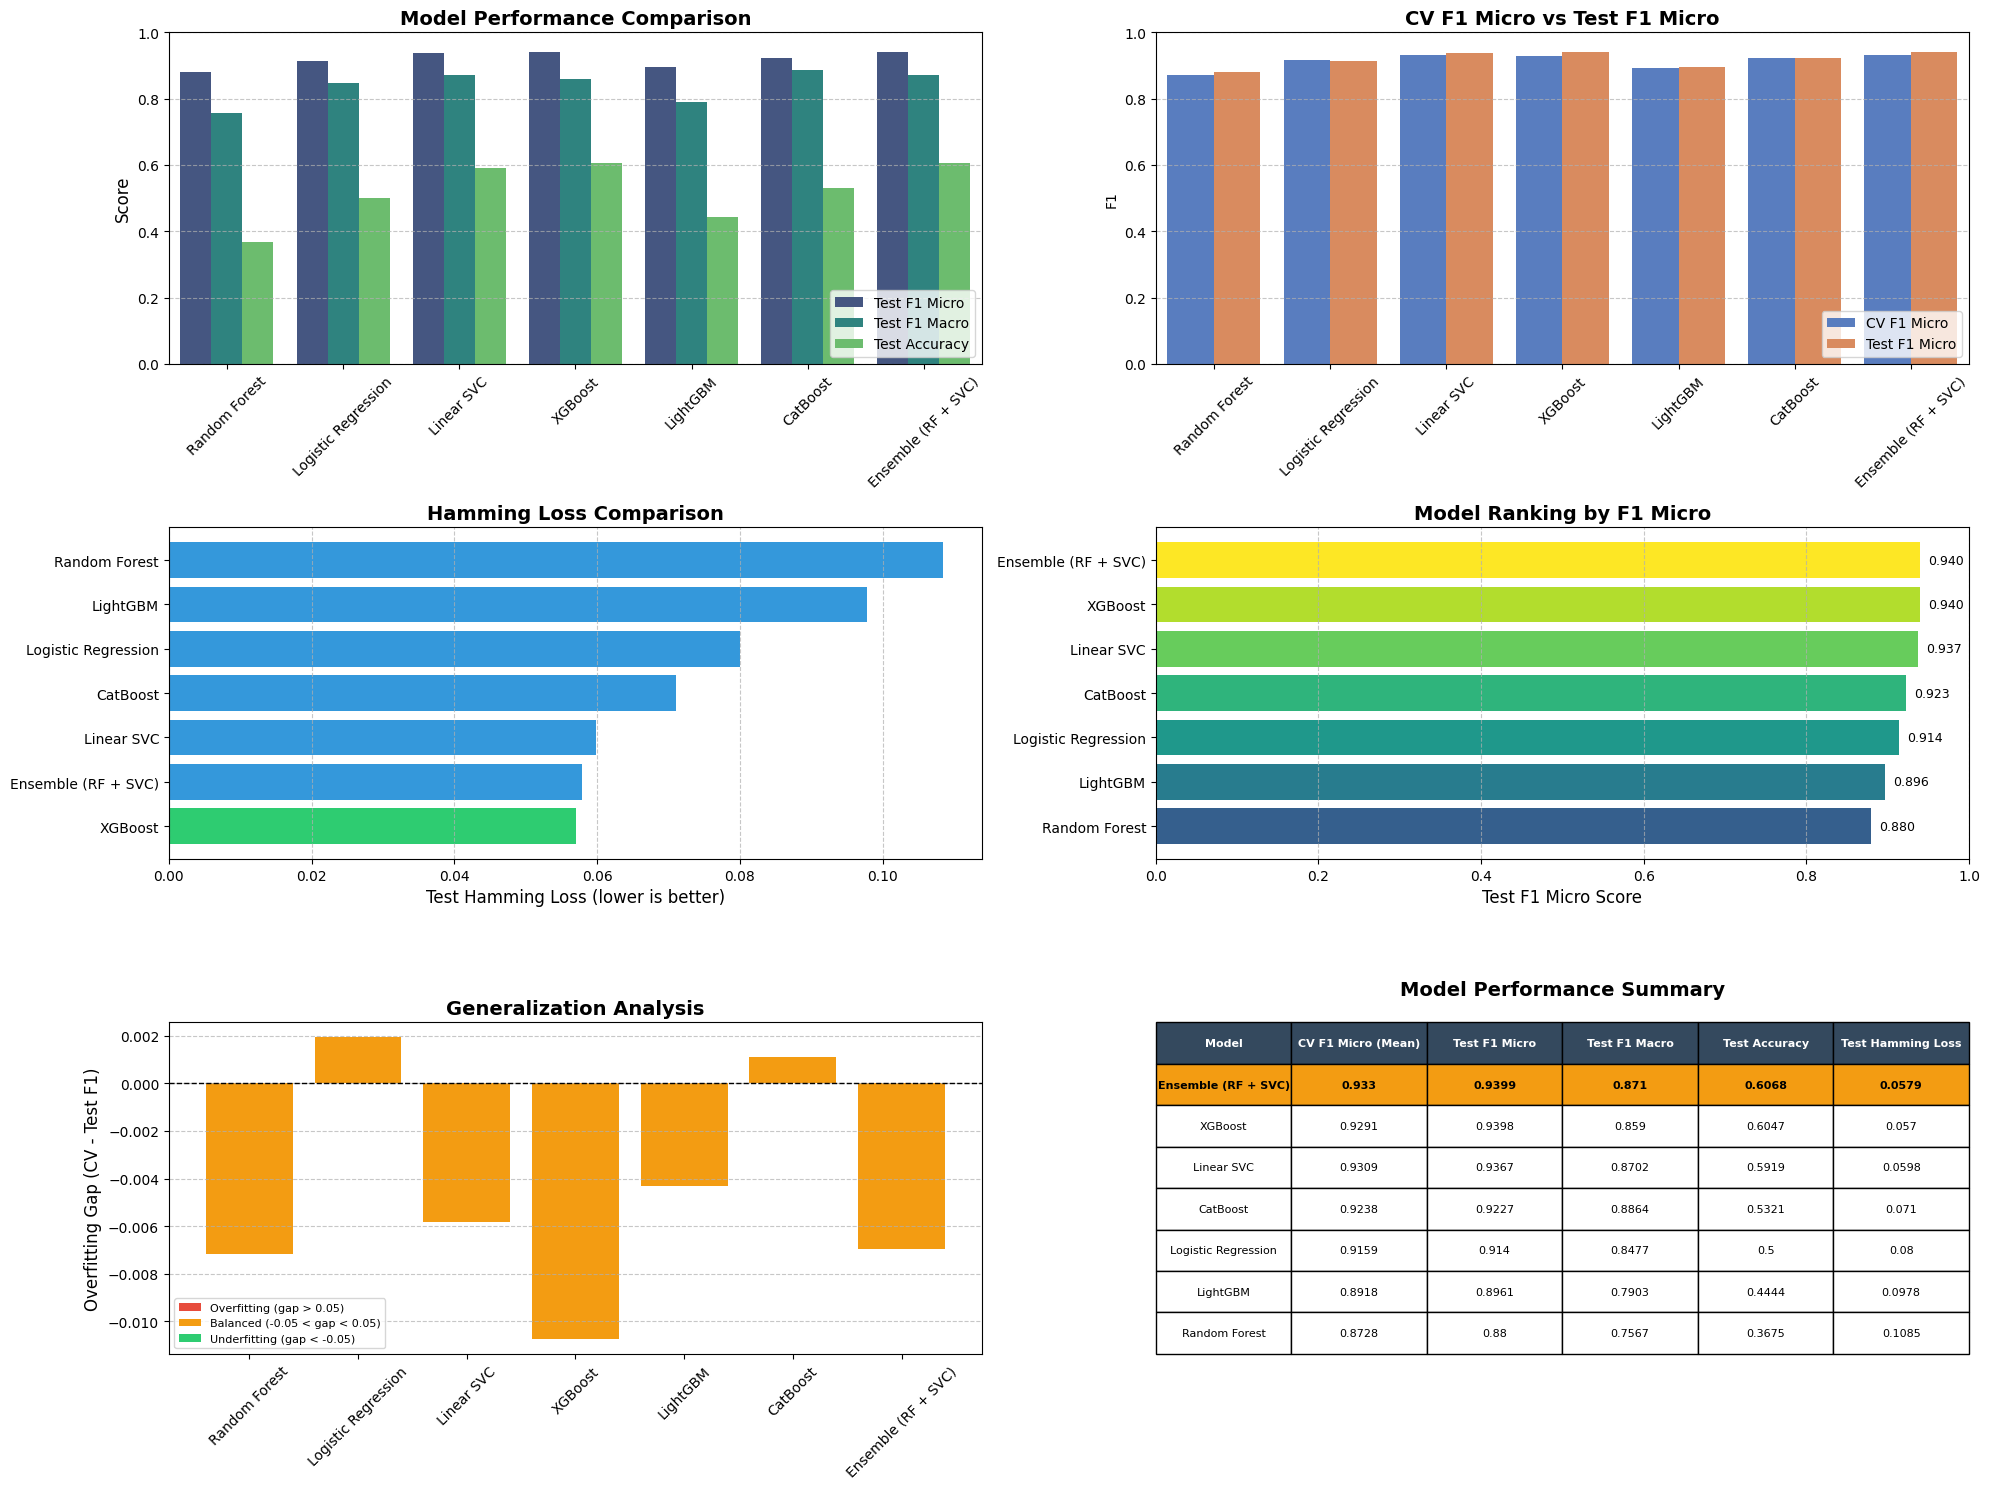


************************************************************
🏆 BEST MODEL: Ensemble (RF + SVC)
************************************************************
   Test F1 Micro:     0.9399
   Test F1 Macro:     0.8710
   Test Accuracy:     0.6068
   Test Hamming Loss: 0.0579
   CV F1 Micro:       0.9330
************************************************************


⚡ GRADIENT BOOSTING MODELS COMPARISON:
   Model  Test F1 Micro  CV F1 Micro (Mean)  Test Accuracy
 XGBoost       0.939819            0.929088       0.604701
LightGBM       0.896117            0.891790       0.444444
CatBoost       0.922679            0.923761       0.532051

🥇 Best Gradient Boosting Model: XGBoost (F1=0.9398)


In [42]:
# 7. Enhanced Visualization - All Models Comparison
if not results_df.empty:
    print("Visualizing Model Performance...")
    
    # Create comprehensive figure
    fig = plt.figure(figsize=(20, 15))
    
    # 1. Bar Chart - All Metrics
    ax1 = plt.subplot(3, 2, 1)
    results_melted = results_df.melt(
        id_vars="Model", 
        value_vars=["Test F1 Micro", "Test F1 Macro", "Test Accuracy"],
        var_name="Metric", 
        value_name="Score"
    )
    sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric", palette="viridis", ax=ax1)
    ax1.set_title("Model Performance Comparison", fontsize=14, fontweight='bold')
    ax1.set_ylim(0, 1.0)
    ax1.set_ylabel("Score", fontsize=12)
    ax1.set_xlabel("")
    ax1.legend(loc='lower right')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    ax1.tick_params(axis='x', rotation=45)
    
    # 2. CV vs Test F1 Micro
    ax2 = plt.subplot(3, 2, 2)
    comp_df = results_df[['Model', 'CV F1 Micro (Mean)', 'Test F1 Micro']].copy()
    comp_df = comp_df.rename(columns={'CV F1 Micro (Mean)': 'CV F1 Micro'})
    melt_df = comp_df.melt(id_vars='Model', var_name='Metric', value_name='F1')
    sns.barplot(data=melt_df, x='Model', y='F1', hue='Metric', palette='muted', ax=ax2)
    ax2.set_title('CV F1 Micro vs Test F1 Micro', fontsize=14, fontweight='bold')
    ax2.set_ylim(0, 1)
    ax2.set_xlabel("")
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend(loc='lower right')
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    
    # 3. Hamming Loss (Lower is Better)
    ax3 = plt.subplot(3, 2, 3)
    sorted_by_hl = results_df.sort_values('Test Hamming Loss')
    colors_hl = ['#2ecc71' if hl == sorted_by_hl['Test Hamming Loss'].min() else '#3498db' 
                 for hl in sorted_by_hl['Test Hamming Loss']]
    ax3.barh(sorted_by_hl['Model'], sorted_by_hl['Test Hamming Loss'], color=colors_hl)
    ax3.set_xlabel('Test Hamming Loss (lower is better)', fontsize=12)
    ax3.set_title('Hamming Loss Comparison', fontsize=14, fontweight='bold')
    ax3.grid(axis='x', linestyle='--', alpha=0.7)
    
    # 4. F1 Micro Ranking
    ax4 = plt.subplot(3, 2, 4)
    sorted_results = results_df.sort_values('Test F1 Micro', ascending=True)
    colors_rank = plt.cm.viridis(np.linspace(0.3, 1, len(sorted_results)))
    bars = ax4.barh(sorted_results['Model'], sorted_results['Test F1 Micro'], color=colors_rank)
    ax4.set_xlabel('Test F1 Micro Score', fontsize=12)
    ax4.set_title('Model Ranking by F1 Micro', fontsize=14, fontweight='bold')
    ax4.set_xlim(0, 1)
    ax4.grid(axis='x', linestyle='--', alpha=0.7)
    
    # Add value labels on bars
    for i, (idx, row) in enumerate(sorted_results.iterrows()):
        ax4.text(row['Test F1 Micro'] + 0.01, i, f"{row['Test F1 Micro']:.3f}", 
                va='center', fontsize=9)
    
    # 5. Overfitting Analysis
    ax5 = plt.subplot(3, 2, 5)
    results_df['Overfitting Gap'] = results_df['CV F1 Micro (Mean)'] - results_df['Test F1 Micro']
    colors_gap = ['#e74c3c' if gap > 0.05 else '#2ecc71' if gap < -0.05 else '#f39c12' 
                  for gap in results_df['Overfitting Gap']]
    ax5.bar(results_df['Model'], results_df['Overfitting Gap'], color=colors_gap)
    ax5.set_ylabel('Overfitting Gap (CV - Test F1)', fontsize=12)
    ax5.set_title('Generalization Analysis', fontsize=14, fontweight='bold')
    ax5.axhline(y=0, color='black', linestyle='--', linewidth=1)
    ax5.tick_params(axis='x', rotation=45)
    ax5.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Add legend for color coding
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#e74c3c', label='Overfitting (gap > 0.05)'),
        Patch(facecolor='#f39c12', label='Balanced (-0.05 < gap < 0.05)'),
        Patch(facecolor='#2ecc71', label='Underfitting (gap < -0.05)')
    ]
    ax5.legend(handles=legend_elements, loc='best', fontsize=8)
    
    # 6. Summary Table
    ax6 = plt.subplot(3, 2, 6)
    ax6.axis('tight')
    ax6.axis('off')
    
    summary_data = results_df[display_cols].round(4)
    summary_data = summary_data.sort_values(by="Test F1 Micro", ascending=False)
    
    table = ax6.table(
        cellText=summary_data.values,
        colLabels=summary_data.columns,
        cellLoc='center',
        loc='center',
        bbox=[0, 0, 1, 1]
    )
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    table.scale(1.0, 2.0)
    
    # Color header
    for i in range(len(summary_data.columns)):
        table[(0, i)].set_facecolor('#34495e')
        table[(0, i)].set_text_props(weight='bold', color='white')
    
    # Highlight best model row
    for i in range(len(summary_data.columns)):
        table[(1, i)].set_facecolor('#f39c12')
        table[(1, i)].set_text_props(weight='bold')
    
    ax6.set_title('Model Performance Summary', fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

    # Print Best Model Summary
    best_model_row = results_df.loc[results_df['Test F1 Micro'].idxmax()]
    print(f"\n{'*'*60}")
    print(f"🏆 BEST MODEL: {best_model_row['Model']}")
    print(f"{'*'*60}")
    print(f"   Test F1 Micro:     {best_model_row['Test F1 Micro']:.4f}")
    print(f"   Test F1 Macro:     {best_model_row['Test F1 Macro']:.4f}")
    print(f"   Test Accuracy:     {best_model_row['Test Accuracy']:.4f}")
    print(f"   Test Hamming Loss: {best_model_row['Test Hamming Loss']:.4f}")
    print(f"   CV F1 Micro:       {best_model_row['CV F1 Micro (Mean)']:.4f}")
    print(f"{'*'*60}\n")
    
    # Gradient Boosting Comparison
    gb_models = results_df[results_df['Model'].isin(['XGBoost', 'LightGBM', 'CatBoost'])]
    if not gb_models.empty:
        print(f"\n{'='*60}")
        print("⚡ GRADIENT BOOSTING MODELS COMPARISON:")
        print(f"{'='*60}")
        print(gb_models[['Model', 'Test F1 Micro', 'CV F1 Micro (Mean)', 'Test Accuracy']].to_string(index=False))
        
        best_gb = gb_models.loc[gb_models['Test F1 Micro'].idxmax()]
        print(f"\n🥇 Best Gradient Boosting Model: {best_gb['Model']} (F1={best_gb['Test F1 Micro']:.4f})")

🔍 ADVANCED ENSEMBLE ANALYSIS

📈 Generating Learning Curves...
   ⚠️ Skipping learning curve for custom ensemble (not compatible)
   Analyzing Random Forest component instead...
   Testing different tree counts for Random Forest...
   Testing different iterations for XGBoost...


C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [16:39:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [16:39:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [16:39:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\eggoni\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [16:39:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\lear


📊 Generating Confusion Matrices...

🎯 Analyzing Per-Class Performance...


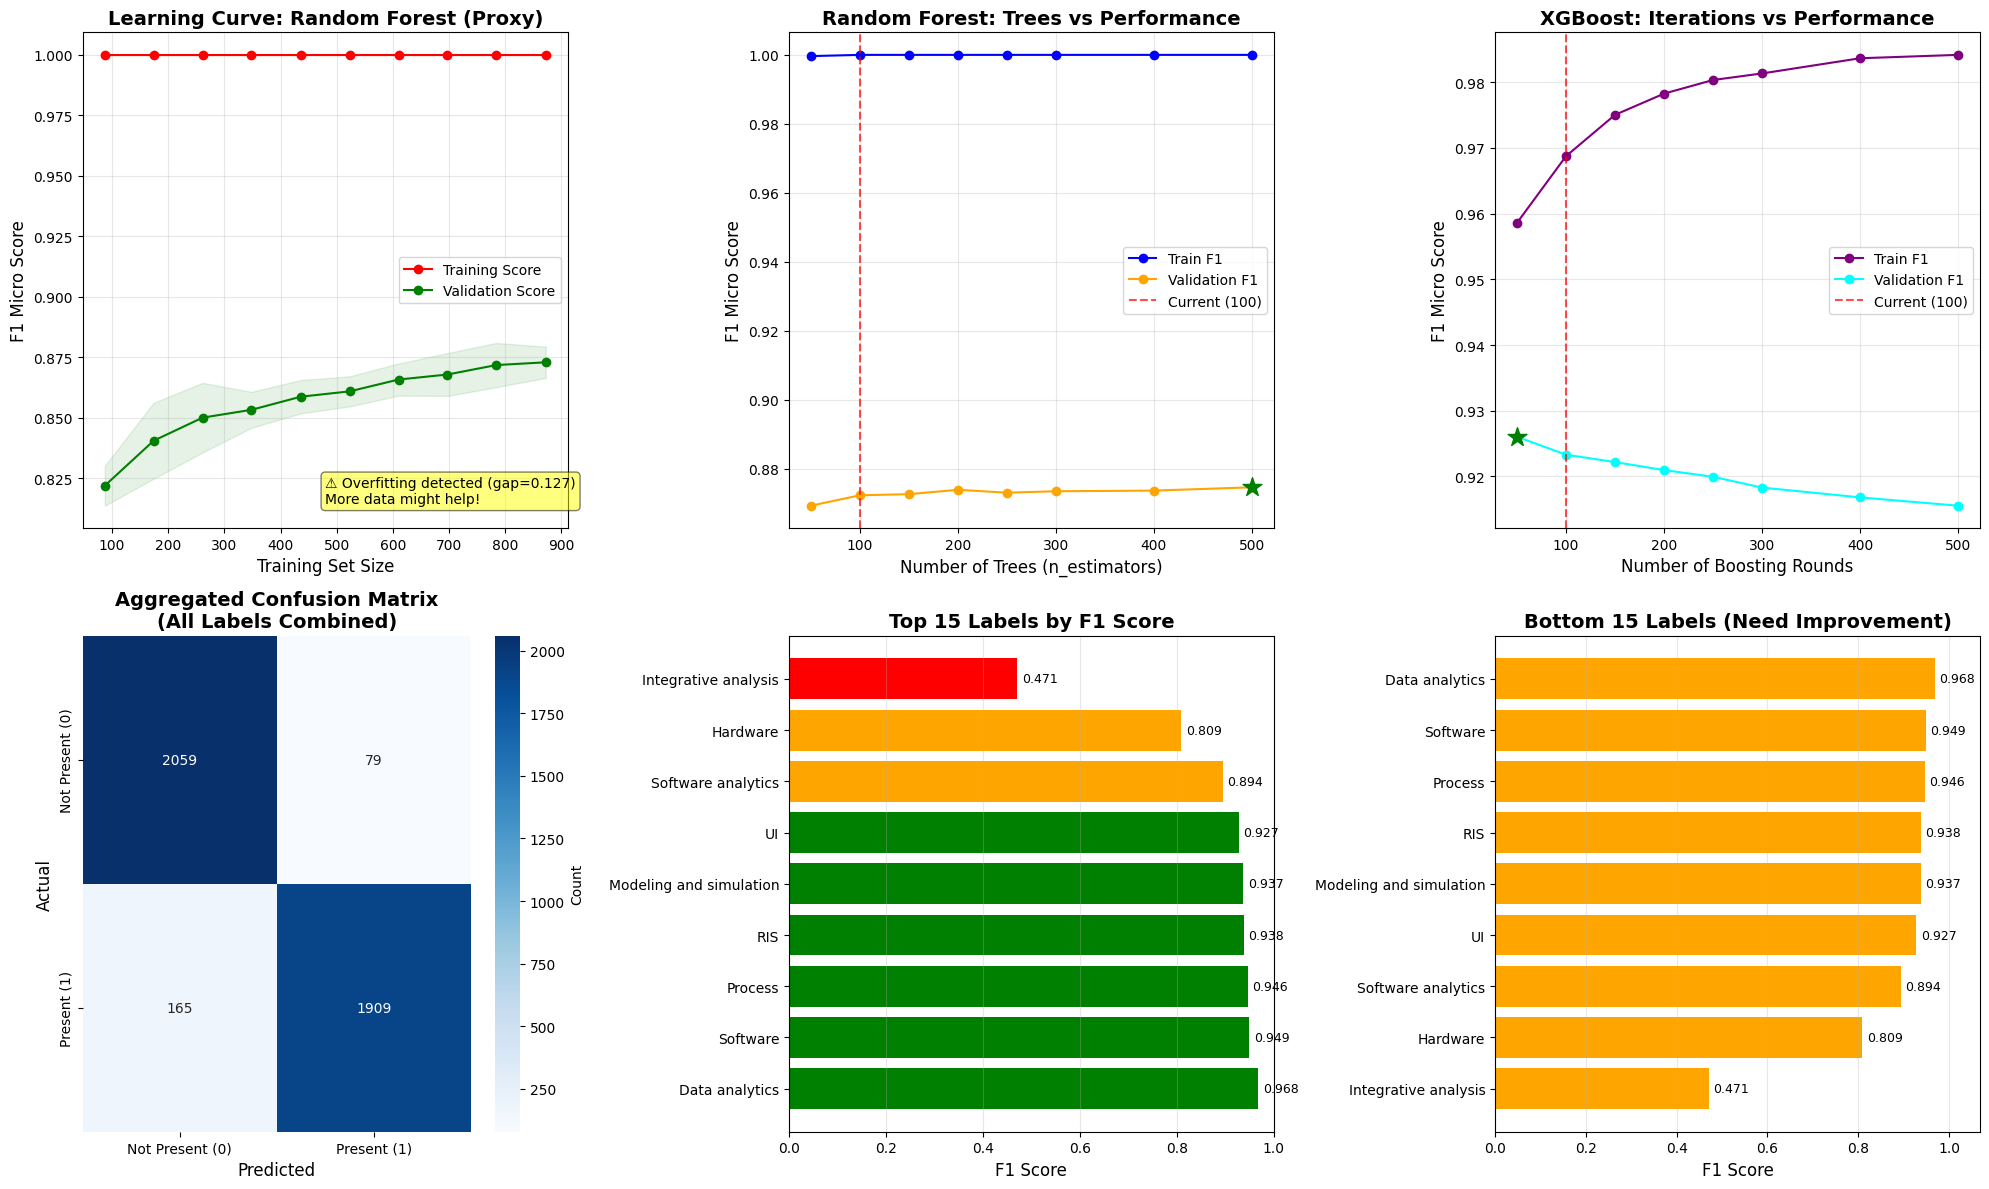


📋 PER-CLASS PERFORMANCE SUMMARY

🏆 TOP 10 BEST PERFORMING LABELS:
                  Label       F1  Precision   Recall  Support
         Data analytics 0.968170   0.981183 0.955497      382
               Software 0.949195   0.959900 0.938725      408
                Process 0.946058   0.970213 0.923077      247
                    RIS 0.937853   0.940510 0.935211      355
Modeling and simulation 0.937213   0.956250 0.918919      333
                     UI 0.927461   0.967568 0.890547      201
     Software analytics 0.894231   0.930000 0.861111      108
               Hardware 0.808511   0.950000 0.703704       27
   Integrative analysis 0.470588   1.000000 0.307692       13

⚠️ BOTTOM 10 LABELS NEEDING IMPROVEMENT:
                  Label       F1  Precision   Recall  Support
         Data analytics 0.968170   0.981183 0.955497      382
               Software 0.949195   0.959900 0.938725      408
                Process 0.946058   0.970213 0.923077      247
                    RIS

In [44]:
# 8. Advanced Ensemble Analysis: Learning Curves, Confusion Matrix, and Per-Class Performance
if not results_df.empty and 'models' in locals():
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.model_selection import learning_curve
    from sklearn.metrics import multilabel_confusion_matrix, confusion_matrix
    import numpy as np
    import pandas as pd
    
    print("="*70)
    print("🔍 ADVANCED ENSEMBLE ANALYSIS")
    print("="*70)
    
    # Get the best model (Ensemble)
    best_model_name = results_df.loc[results_df['Test F1 Micro'].idxmax()]['Model']
    best_clf = models[best_model_name]
    
    # ============================================================================
    # 1. LEARNING CURVES - Does more data/trees help?
    # ============================================================================
    print("\n📈 Generating Learning Curves...")
    
    fig = plt.figure(figsize=(20, 12))
    
    # --- Learning Curve for Best Model ---
    if best_model_name == "Ensemble (RF + SVC)":
        print("   ⚠️ Skipping learning curve for custom ensemble (not compatible)")
        print("   Analyzing Random Forest component instead...")
        
        # Use Random Forest as proxy for ensemble analysis
        rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
        
        # Plot 1: Learning curve (data size vs performance)
        ax1 = plt.subplot(2, 3, 1)
        train_sizes = np.linspace(0.1, 1.0, 10)
        
        train_sizes_abs, train_scores, val_scores = learning_curve(
            rf_model, X_train, y_train,
            train_sizes=train_sizes,
            cv=5,
            scoring='f1_micro',
            n_jobs=-1,
            random_state=42
        )
        
        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        val_mean = np.mean(val_scores, axis=1)
        val_std = np.std(val_scores, axis=1)
        
        ax1.plot(train_sizes_abs, train_mean, 'o-', color='r', label='Training Score')
        ax1.plot(train_sizes_abs, val_mean, 'o-', color='g', label='Validation Score')
        ax1.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
        ax1.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.1, color='g')
        ax1.set_xlabel('Training Set Size', fontsize=12)
        ax1.set_ylabel('F1 Micro Score', fontsize=12)
        ax1.set_title('Learning Curve: Random Forest (Proxy)', fontsize=14, fontweight='bold')
        ax1.legend(loc='best')
        ax1.grid(True, alpha=0.3)
        
        # Analysis
        gap = train_mean[-1] - val_mean[-1]
        if gap > 0.05:
            ax1.text(0.5, 0.05, f'⚠️ Overfitting detected (gap={gap:.3f})\nMore data might help!', 
                    transform=ax1.transAxes, fontsize=10, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
        else:
            ax1.text(0.5, 0.05, f'✅ Good generalization (gap={gap:.3f})', 
                    transform=ax1.transAxes, fontsize=10, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    else:
        # For non-ensemble models, use directly
        print(f"   Analyzing {best_model_name}...")
        
        ax1 = plt.subplot(2, 3, 1)
        train_sizes = np.linspace(0.1, 1.0, 10)
        
        try:
            train_sizes_abs, train_scores, val_scores = learning_curve(
                best_clf, X_train, y_train,
                train_sizes=train_sizes,
                cv=5,
                scoring='f1_micro',
                n_jobs=-1,
                random_state=42
            )
            
            train_mean = np.mean(train_scores, axis=1)
            train_std = np.std(train_scores, axis=1)
            val_mean = np.mean(val_scores, axis=1)
            val_std = np.std(val_scores, axis=1)
            
            ax1.plot(train_sizes_abs, train_mean, 'o-', color='r', label='Training Score')
            ax1.plot(train_sizes_abs, val_mean, 'o-', color='g', label='Validation Score')
            ax1.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
            ax1.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.1, color='g')
            ax1.set_xlabel('Training Set Size', fontsize=12)
            ax1.set_ylabel('F1 Micro Score', fontsize=12)
            ax1.set_title(f'Learning Curve: {best_model_name}', fontsize=14, fontweight='bold')
            ax1.legend(loc='best')
            ax1.grid(True, alpha=0.3)
            
            gap = train_mean[-1] - val_mean[-1]
            if gap > 0.05:
                ax1.text(0.5, 0.05, f'⚠️ Overfitting detected (gap={gap:.3f})', 
                        transform=ax1.transAxes, fontsize=10, bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
            else:
                ax1.text(0.5, 0.05, f'✅ Good generalization (gap={gap:.3f})', 
                        transform=ax1.transAxes, fontsize=10, bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
        except Exception as e:
            ax1.text(0.5, 0.5, f'Learning curve failed:\n{str(e)}', 
                    transform=ax1.transAxes, ha='center', va='center', fontsize=10)
            ax1.set_title(f'Learning Curve: {best_model_name} (Error)', fontsize=14, fontweight='bold')
    
    # --- Compare Different n_estimators for Random Forest ---
    print("   Testing different tree counts for Random Forest...")
    ax2 = plt.subplot(2, 3, 2)
    
    n_estimator_range = [50, 100, 150, 200, 250, 300, 400, 500]
    rf_train_scores = []
    rf_val_scores = []
    
    for n_est in n_estimator_range:
        rf_temp = RandomForestClassifier(n_estimators=n_est, class_weight='balanced', random_state=42, n_jobs=-1)
        cv_scores = cross_validate(rf_temp, X_train, y_train, cv=3, scoring='f1_micro', return_train_score=True)
        rf_train_scores.append(np.mean(cv_scores['train_score']))
        rf_val_scores.append(np.mean(cv_scores['test_score']))
    
    ax2.plot(n_estimator_range, rf_train_scores, 'o-', label='Train F1', color='blue')
    ax2.plot(n_estimator_range, rf_val_scores, 'o-', label='Validation F1', color='orange')
    ax2.axvline(x=100, color='red', linestyle='--', label='Current (100)', alpha=0.7)
    ax2.set_xlabel('Number of Trees (n_estimators)', fontsize=12)
    ax2.set_ylabel('F1 Micro Score', fontsize=12)
    ax2.set_title('Random Forest: Trees vs Performance', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Find optimal
    optimal_idx = np.argmax(rf_val_scores)
    optimal_n = n_estimator_range[optimal_idx]
    ax2.scatter(optimal_n, rf_val_scores[optimal_idx], s=200, color='green', marker='*', zorder=5, label=f'Best: {optimal_n}')
    
    # --- Compare Different iterations for XGBoost ---
    print("   Testing different iterations for XGBoost...")
    ax3 = plt.subplot(2, 3, 3)
    
    iteration_range = [50, 100, 150, 200, 250, 300, 400, 500]
    xgb_train_scores = []
    xgb_val_scores = []
    
    for n_iter in iteration_range:
        xgb_temp = OneVsRestClassifier(xgb.XGBClassifier(
            n_estimators=n_iter, max_depth=6, learning_rate=0.1, 
            random_state=42, eval_metric='logloss', use_label_encoder=False
        ))
        cv_scores = cross_validate(xgb_temp, X_train, y_train, cv=3, scoring='f1_micro', return_train_score=True)
        xgb_train_scores.append(np.mean(cv_scores['train_score']))
        xgb_val_scores.append(np.mean(cv_scores['test_score']))
    
    ax3.plot(iteration_range, xgb_train_scores, 'o-', label='Train F1', color='purple')
    ax3.plot(iteration_range, xgb_val_scores, 'o-', label='Validation F1', color='cyan')
    ax3.axvline(x=100, color='red', linestyle='--', label='Current (100)', alpha=0.7)
    ax3.set_xlabel('Number of Boosting Rounds', fontsize=12)
    ax3.set_ylabel('F1 Micro Score', fontsize=12)
    ax3.set_title('XGBoost: Iterations vs Performance', fontsize=14, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    optimal_xgb_idx = np.argmax(xgb_val_scores)
    optimal_xgb_n = iteration_range[optimal_xgb_idx]
    ax3.scatter(optimal_xgb_n, xgb_val_scores[optimal_xgb_idx], s=200, color='green', marker='*', zorder=5)
    
    # ============================================================================
    # 2. CONFUSION MATRIX - Multi-label Version
    # ============================================================================
    print("\n📊 Generating Confusion Matrices...")
    
    y_pred_ensemble = best_clf.predict(X_test)
    
    # Plot 4: Overall Confusion Matrix (Aggregated)
    ax4 = plt.subplot(2, 3, 4)
    
    # Flatten all predictions and actuals for aggregated view
    y_test_flat = y_test.ravel()
    y_pred_flat = y_pred_ensemble.ravel()
    
    cm = confusion_matrix(y_test_flat, y_pred_flat)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4, cbar_kws={'label': 'Count'})
    ax4.set_xlabel('Predicted', fontsize=12)
    ax4.set_ylabel('Actual', fontsize=12)
    ax4.set_title('Aggregated Confusion Matrix\n(All Labels Combined)', fontsize=14, fontweight='bold')
    ax4.set_xticklabels(['Not Present (0)', 'Present (1)'])
    ax4.set_yticklabels(['Not Present (0)', 'Present (1)'])
    
    # ============================================================================
    # 3. PER-CLASS PERFORMANCE
    # ============================================================================
    print("\n🎯 Analyzing Per-Class Performance...")
    
    # Plot 5: Top 15 Labels by F1 Score
    ax5 = plt.subplot(2, 3, 5)
    
    per_class_f1 = f1_score(y_test, y_pred_ensemble, average=None)
    per_class_df = pd.DataFrame({
        'Label': mlb_y.classes_,
        'F1 Score': per_class_f1
    }).sort_values('F1 Score', ascending=False)
    
    top_15 = per_class_df.head(15)
    colors_f1 = ['green' if f1 > 0.9 else 'orange' if f1 > 0.7 else 'red' for f1 in top_15['F1 Score']]
    
    ax5.barh(top_15['Label'], top_15['F1 Score'], color=colors_f1)
    ax5.set_xlabel('F1 Score', fontsize=12)
    ax5.set_title('Top 15 Labels by F1 Score', fontsize=14, fontweight='bold')
    ax5.set_xlim(0, 1)
    ax5.grid(axis='x', alpha=0.3)
    
    for i, (label, f1) in enumerate(zip(top_15['Label'], top_15['F1 Score'])):
        ax5.text(f1 + 0.01, i, f'{f1:.3f}', va='center', fontsize=9)
    
    # Plot 6: Bottom 15 Labels (Problematic Classes)
    ax6 = plt.subplot(2, 3, 6)
    
    bottom_15 = per_class_df.tail(15).sort_values('F1 Score', ascending=True)
    colors_bottom = ['red' if f1 < 0.3 else 'orange' for f1 in bottom_15['F1 Score']]
    
    ax6.barh(bottom_15['Label'], bottom_15['F1 Score'], color=colors_bottom)
    ax6.set_xlabel('F1 Score', fontsize=12)
    ax6.set_title('Bottom 15 Labels (Need Improvement)', fontsize=14, fontweight='bold')
    ax6.set_xlim(0, max(bottom_15['F1 Score']) + 0.1)
    ax6.grid(axis='x', alpha=0.3)
    
    for i, (label, f1) in enumerate(zip(bottom_15['Label'], bottom_15['F1 Score'])):
        ax6.text(f1 + 0.01, i, f'{f1:.3f}', va='center', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    # ============================================================================
    # 4. DETAILED STATISTICS TABLE
    # ============================================================================
    print(f"\n{'='*70}")
    print("📋 PER-CLASS PERFORMANCE SUMMARY")
    print(f"{'='*70}")
    
    # Calculate additional metrics per class
    per_class_precision = []
    per_class_recall = []
    per_class_support = []
    
    for i in range(y_test.shape[1]):
        y_true_class = y_test[:, i]
        y_pred_class = y_pred_ensemble[:, i]
        
        tp = np.sum((y_true_class == 1) & (y_pred_class == 1))
        fp = np.sum((y_true_class == 0) & (y_pred_class == 1))
        fn = np.sum((y_true_class == 1) & (y_pred_class == 0))
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        support = np.sum(y_true_class)
        
        per_class_precision.append(precision)
        per_class_recall.append(recall)
        per_class_support.append(support)
    
    detailed_df = pd.DataFrame({
        'Label': mlb_y.classes_,
        'F1': per_class_f1,
        'Precision': per_class_precision,
        'Recall': per_class_recall,
        'Support': per_class_support
    }).sort_values('F1', ascending=False)
    
    print("\n🏆 TOP 10 BEST PERFORMING LABELS:")
    print(detailed_df.head(10).to_string(index=False))
    
    print("\n⚠️ BOTTOM 10 LABELS NEEDING IMPROVEMENT:")
    print(detailed_df.tail(10).to_string(index=False))
    
    # ============================================================================
    # 5. RECOMMENDATIONS
    # ============================================================================
    print(f"\n{'='*70}")
    print("💡 RECOMMENDATIONS BASED ON ANALYSIS")
    print(f"{'='*70}")
    
    # Check if more trees would help
    if optimal_n > 100:
        print(f"\n✅ Random Forest: Increase to {optimal_n} trees (current: 100)")
        print(f"   Expected improvement: {(rf_val_scores[optimal_idx] - rf_val_scores[1])*100:.2f}%")
    else:
        print(f"\n✅ Random Forest: Current 100 trees is optimal")
    
    if optimal_xgb_n > 100:
        print(f"\n✅ XGBoost: Increase to {optimal_xgb_n} iterations (current: 100)")
        print(f"   Expected improvement: {(xgb_val_scores[optimal_xgb_idx] - xgb_val_scores[1])*100:.2f}%")
    else:
        print(f"\n✅ XGBoost: Current 100 iterations is optimal")
    
    # Check for class imbalance issues
    low_f1_labels = detailed_df[detailed_df['F1'] < 0.5]
    if len(low_f1_labels) > 0:
        print(f"\n⚠️ {len(low_f1_labels)} labels have F1 < 0.5:")
        print("   Consider:")
        print("   - Collecting more samples for these labels")
        print("   - Adjusting class weights further")
        print("   - Using SMOTE or other oversampling techniques")
    
    # Memory and performance trade-offs
    print(f"\n📊 Model Complexity Analysis:")
    if best_model_name == "Ensemble (RF + SVC)":
        print(f"   Current Ensemble trains: {100} RF trees + {2000} SVC iterations")
        print(f"   Optimal Ensemble would train: {optimal_n} RF trees + SVC")
        print(f"   Training time increase: ~{(optimal_n/100 - 1)*100:.0f}%")
    else:
        print(f"   Best model: {best_model_name}")
        print(f"   Recommended tuning based on learning curves above")
    
    print(f"\n{'='*70}")
    
else:
    print("⚠️ No results available. Please run the training cells first.")

In [49]:
!pip install pytest

Defaulting to user installation because normal site-packages is not writeable

   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   -------------------------- ------------- 2/3 [pytest]
   ---------------------------------------- 3/3 [pytest]




[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


🔍 MULTI-LABEL CONFUSION MATRIX ANALYSIS (9 LABELS)

Generating confusion matrices for all 9 labels...
✅ Generated 9 confusion matrices

📊 Creating 3x3 grid visualization...


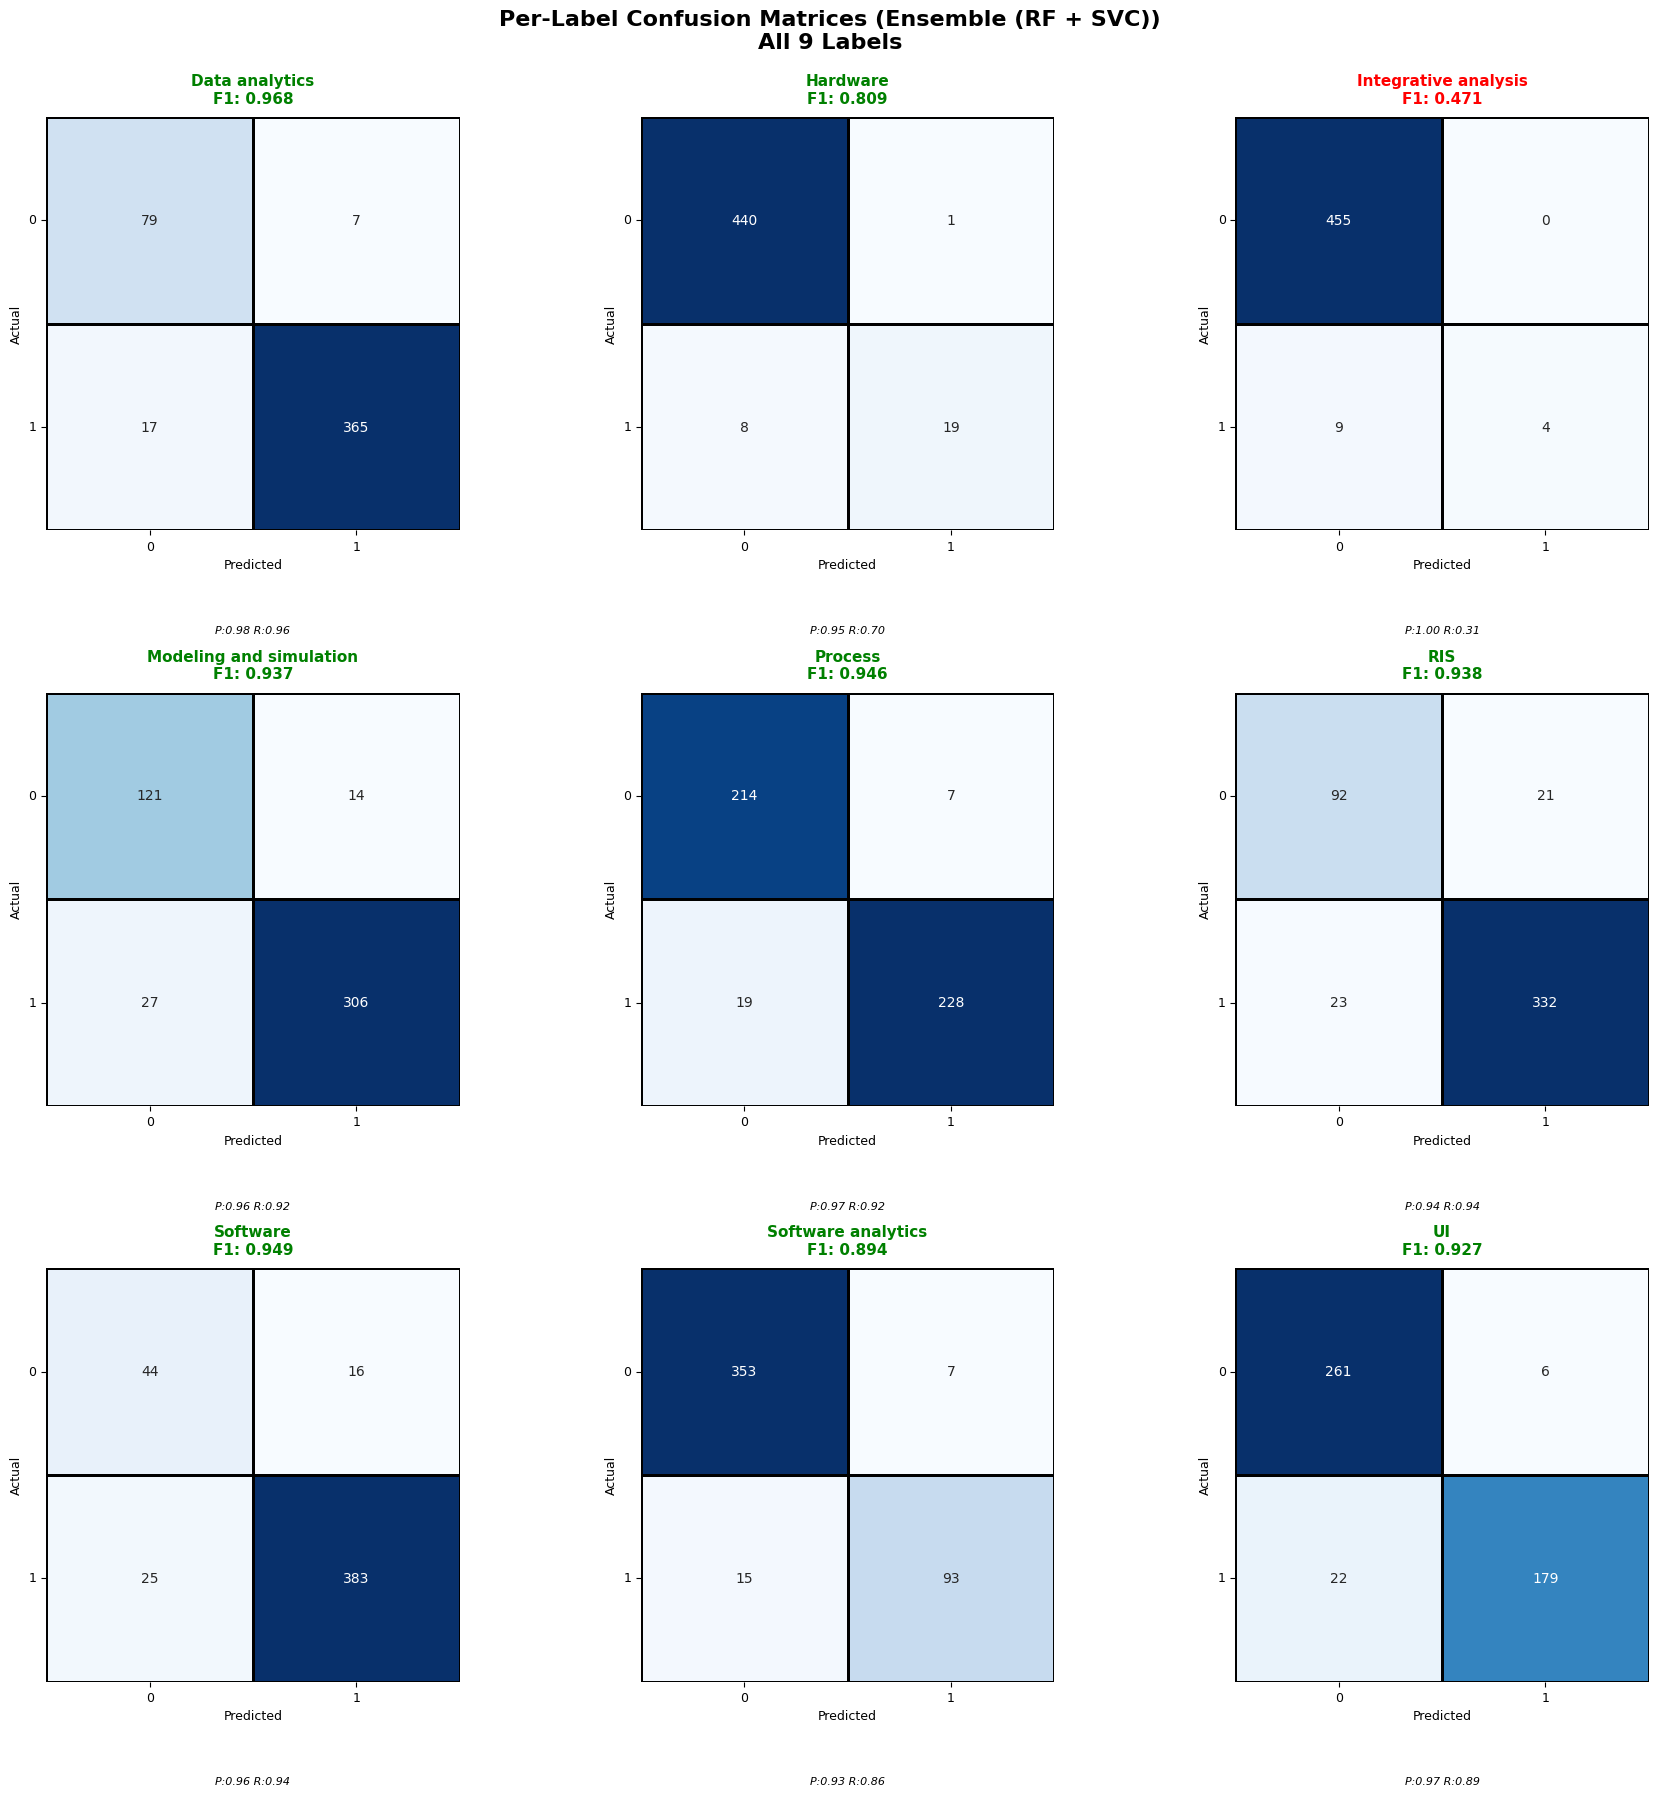


📋 DETAILED PER-LABEL CONFUSION MATRIX STATISTICS

                  Label  TP  FP  FN  TN  Precision   Recall       F1  Support
         Data analytics 365   7  17  79   0.981183 0.955497 0.968170      382
               Software 383  16  25  44   0.959900 0.938725 0.949195      408
                Process 228   7  19 214   0.970213 0.923077 0.946058      247
                    RIS 332  21  23  92   0.940510 0.935211 0.937853      355
Modeling and simulation 306  14  27 121   0.956250 0.918919 0.937213      333
                     UI 179   6  22 261   0.967568 0.890547 0.927461      201
     Software analytics  93   7  15 353   0.930000 0.861111 0.894231      108
               Hardware  19   1   8 440   0.950000 0.703704 0.808511       27
   Integrative analysis   4   0   9 455   1.000000 0.307692 0.470588       13

📊 AGGREGATED CONFUSION MATRIX (ALL LABELS COMBINED)



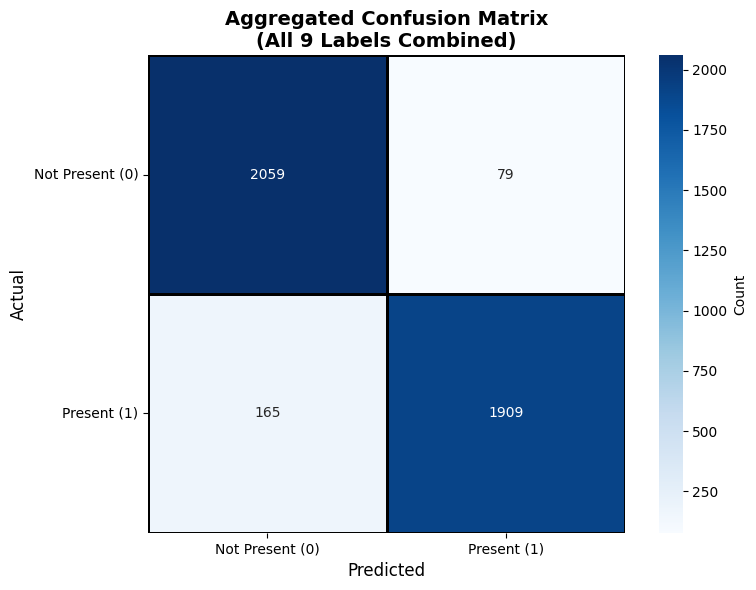

Aggregated Statistics:
  True Negatives (TN):  2,059
  False Positives (FP): 79
  False Negatives (FN): 165
  True Positives (TP):  1,909
  Total Predictions:    4,212

  Aggregated Precision: 0.9603
  Aggregated Recall:    0.9204
  Aggregated F1:        0.9399

🏆 TOP 3 BEST PERFORMING LABELS:

Data analytics:
  F1 Score:  0.9682
  Precision: 0.9812
  Recall:    0.9555
  Support:   382

Software:
  F1 Score:  0.9492
  Precision: 0.9599
  Recall:    0.9387
  Support:   408

Process:
  F1 Score:  0.9461
  Precision: 0.9702
  Recall:    0.9231
  Support:   247

⚠️ TOP 3 WORST PERFORMING LABELS:

Software analytics:
  F1 Score:  0.8942
  Precision: 0.9300
  Recall:    0.8611
  Support:   108
  Issue: High False Negatives (15) - Model misses this label

Hardware:
  F1 Score:  0.8085
  Precision: 0.9500
  Recall:    0.7037
  Support:   27
  Issue: High False Negatives (8) - Model misses this label

Integrative analysis:
  F1 Score:  0.4706
  Precision: 1.0000
  Recall:    0.3077
  Support:  

In [51]:
# 9. Multi-Label Confusion Matrix Visualization for 9 Labels (Ensemble Model)
if not results_df.empty and 'models' in locals():
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.metrics import multilabel_confusion_matrix, confusion_matrix, f1_score, precision_score, recall_score
    import numpy as np
    import pandas as pd
    
    print("="*70)
    print("🔍 MULTI-LABEL CONFUSION MATRIX ANALYSIS (9 LABELS)")
    print("="*70)
    
    # Get the best model (Ensemble)
    best_model_name = results_df.loc[results_df['Test F1 Micro'].idxmax()]['Model']
    best_clf = models[best_model_name]
    
    # Get predictions
    y_pred_ensemble = best_clf.predict(X_test)
    
    # ============================================================================
    # 1. GENERATE MULTI-LABEL CONFUSION MATRICES (One per label)
    # ============================================================================
    print(f"\nGenerating confusion matrices for all {len(mlb_y.classes_)} labels...")
    
    mcm = multilabel_confusion_matrix(y_test, y_pred_ensemble)
    
    print(f"✅ Generated {mcm.shape[0]} confusion matrices")
    
    # ============================================================================
    # 2. VISUALIZE ALL 9 CONFUSION MATRICES IN A 3x3 GRID
    # ============================================================================
    print("\n📊 Creating 3x3 grid visualization...")
    
    # Calculate grid size (3x3 for 9 labels)
    n_labels = len(mlb_y.classes_)
    grid_rows = 3
    grid_cols = 3
    
    fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(18, 18))
    axes = axes.ravel()
    
    for i, (cm, label) in enumerate(zip(mcm, mlb_y.classes_)):
        ax = axes[i]
        
        # Extract confusion matrix values
        tn, fp, fn, tp = cm.ravel()
        
        # Create heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                   cbar=False, square=True, linewidths=1, linecolor='black')
        
        # Calculate metrics for this label
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        
        # Color-code title based on F1 score
        if f1 > 0.8:
            title_color = 'green'
        elif f1 > 0.5:
            title_color = 'orange'
        else:
            title_color = 'red'
        
        ax.set_title(f'{label}\nF1: {f1:.3f}', 
                    fontsize=11, fontweight='bold', color=title_color, pad=10)
        ax.set_xlabel('Predicted', fontsize=9)
        ax.set_ylabel('Actual', fontsize=9)
        ax.set_xticklabels(['0', '1'], fontsize=9)
        ax.set_yticklabels(['0', '1'], fontsize=9, rotation=0)
        
        # Add small text with metrics
        ax.text(0.5, -0.25, f'P:{precision:.2f} R:{recall:.2f}', 
               transform=ax.transAxes, ha='center', fontsize=8, style='italic')
    
    plt.suptitle(f'Per-Label Confusion Matrices ({best_model_name})\nAll {n_labels} Labels', 
                fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()
    
    # ============================================================================
    # 3. DETAILED PER-LABEL STATISTICS TABLE
    # ============================================================================
    print(f"\n{'='*70}")
    print("📋 DETAILED PER-LABEL CONFUSION MATRIX STATISTICS")
    print(f"{'='*70}\n")
    
    detailed_stats = []
    
    for i, (cm, label) in enumerate(zip(mcm, mlb_y.classes_)):
        tn, fp, fn, tp = cm.ravel()
        
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        support = tp + fn  # Total actual positives
        
        detailed_stats.append({
            'Label': label,
            'TP': tp,
            'FP': fp,
            'FN': fn,
            'TN': tn,
            'Precision': precision,
            'Recall': recall,
            'F1': f1,
            'Support': support
        })
    
    stats_df = pd.DataFrame(detailed_stats)
    stats_df = stats_df.sort_values('F1', ascending=False)
    
    print(stats_df.to_string(index=False))
    
    # ============================================================================
    # 4. AGGREGATED CONFUSION MATRIX (All Labels Combined)
    # ============================================================================
    print(f"\n{'='*70}")
    print("📊 AGGREGATED CONFUSION MATRIX (ALL LABELS COMBINED)")
    print(f"{'='*70}\n")
    
    # Flatten all predictions and actuals
    y_test_flat = y_test.ravel()
    y_pred_flat = y_pred_ensemble.ravel()
    
    cm_aggregated = confusion_matrix(y_test_flat, y_pred_flat)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_aggregated, annot=True, fmt='d', cmap='Blues', 
               cbar_kws={'label': 'Count'}, square=True, linewidths=2, linecolor='black')
    plt.title(f'Aggregated Confusion Matrix\n(All {n_labels} Labels Combined)', 
             fontsize=14, fontweight='bold')
    plt.xlabel('Predicted', fontsize=12)
    plt.ylabel('Actual', fontsize=12)
    plt.xticks([0.5, 1.5], ['Not Present (0)', 'Present (1)'])
    plt.yticks([0.5, 1.5], ['Not Present (0)', 'Present (1)'], rotation=0)
    plt.tight_layout()
    plt.show()
    
    # Print aggregated stats
    tn_agg, fp_agg, fn_agg, tp_agg = cm_aggregated.ravel()
    
    print(f"Aggregated Statistics:")
    print(f"  True Negatives (TN):  {tn_agg:,}")
    print(f"  False Positives (FP): {fp_agg:,}")
    print(f"  False Negatives (FN): {fn_agg:,}")
    print(f"  True Positives (TP):  {tp_agg:,}")
    print(f"  Total Predictions:    {tn_agg + fp_agg + fn_agg + tp_agg:,}")
    
    precision_agg = tp_agg / (tp_agg + fp_agg) if (tp_agg + fp_agg) > 0 else 0
    recall_agg = tp_agg / (tp_agg + fn_agg) if (tp_agg + fn_agg) > 0 else 0
    f1_agg = 2 * precision_agg * recall_agg / (precision_agg + recall_agg) if (precision_agg + recall_agg) > 0 else 0
    
    print(f"\n  Aggregated Precision: {precision_agg:.4f}")
    print(f"  Aggregated Recall:    {recall_agg:.4f}")
    print(f"  Aggregated F1:        {f1_agg:.4f}")
    
    # ============================================================================
    # 5. SUMMARY: BEST AND WORST PERFORMING LABELS
    # ============================================================================
    print(f"\n{'='*70}")
    print("🏆 TOP 3 BEST PERFORMING LABELS:")
    print(f"{'='*70}")
    top_3 = stats_df.head(3)
    for idx, row in top_3.iterrows():
        print(f"\n{row['Label']}:")
        print(f"  F1 Score:  {row['F1']:.4f}")
        print(f"  Precision: {row['Precision']:.4f}")
        print(f"  Recall:    {row['Recall']:.4f}")
        print(f"  Support:   {row['Support']}")
    
    print(f"\n{'='*70}")
    print("⚠️ TOP 3 WORST PERFORMING LABELS:")
    print(f"{'='*70}")
    bottom_3 = stats_df.tail(3)
    for idx, row in bottom_3.iterrows():
        print(f"\n{row['Label']}:")
        print(f"  F1 Score:  {row['F1']:.4f}")
        print(f"  Precision: {row['Precision']:.4f}")
        print(f"  Recall:    {row['Recall']:.4f}")
        print(f"  Support:   {row['Support']}")
        print(f"  Issue: ", end="")
        if row['FN'] > row['FP']:
            print(f"High False Negatives ({row['FN']}) - Model misses this label")
        elif row['FP'] > row['FN']:
            print(f"High False Positives ({row['FP']}) - Model over-predicts this label")
        else:
            print(f"Low support ({row['Support']}) - Not enough training data")
    
    print(f"\n{'='*70}")
    
else:
    print("⚠️ No results available. Please run the training cells first.")